# Librerías

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, classification_report,accuracy_score, precision_score, recall_score, f1_score,roc_curve,precision_recall_curve, average_precision_score,balanced_accuracy_score
from scipy.stats import chi2_contingency
from sklearn.feature_selection import chi2
from sklearn.preprocessing import KBinsDiscretizer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pointbiserialr

from upsetplot import UpSet, from_memberships

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

from upsetplot import UpSet, from_memberships



from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')

# Funciones

In [29]:
def leer_dataset():
    df = pd.read_csv('data.csv')
    # lista de columnas a eliminar
    cols_to_drop = ['ALEAT', 'ID','VT']  # reemplaza por los nombres reales
    df = df.drop(columns=cols_to_drop)
    df.rename(columns={'V31_P': 'V31'}, inplace=True)
    df.rename(columns={'V31_P.1': 'V31_P'}, inplace=True)
    # lista de columnas a eliminar
    cols_to_drop = ['V14', 'V14_P']  

    # hacer el drop
    df = df.drop(columns=cols_to_drop)
    df['OBJ']=df['OBJ'].map({'NO':0,'SI':1})
    
    return df
def subset_datos(df):
    #Separar grupos de datos en absolutos y relativos
    absolutas=[col for col in df.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
    relativas=[col for col in df.columns if '_P' in col]
    return df[absolutas], df[relativas], df['OBJ']
def plot_boxplot(df, columnas, titulo='Boxplot'):
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df[columnas])
    plt.title(titulo)
    plt.xticks(rotation=90)
    plt.show()
def recalculate_relative_variables(df, absolute_columns, relative_suffix='_P', total_column='VT'):
    """
    Recalcula las variables relativas V*_P como V* / VT, donde VT es la suma de las columnas absolutas.
    
    Args:
        df (pd.DataFrame): el dataframe original.
        absolute_columns (list): lista de columnas absolutas (ej. V1, V2, V3...).
        relative_suffix (str): sufijo que se añade para las columnas relativas (default '_P').
        total_column (str): nombre de la columna de total (default 'VT').
    
    Returns:
        pd.DataFrame: dataframe con las columnas relativas recalculadas.
    """
    df_new = df.copy()
    # Calcular la suma total VT
    df_new[total_column] = df_new[absolute_columns].sum(axis=1)
    
    # Calcular las variables relativas
    for col in absolute_columns:
        perc_col = f"{col}{relative_suffix}"
        df_new[perc_col] = df_new[col] / df_new[total_column]
    
    df_new.drop(columns=absolute_columns + [total_column], inplace=True)

    
    return df_new
def count_outliers_iqr(df, columns, factor=1.5):
    """
    Cuenta la cantidad de outliers por variable usando el criterio IQR.
    
    Args:
        df (pd.DataFrame): dataframe original.
        columns (list): lista de columnas numéricas.
        factor (float): multiplicador del IQR (default 1.5)
        
    Returns:
        pd.DataFrame con columnas ['variable', 'outliers_count', 'outliers_percent']
    """
    outliers_summary = []
    
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        count = outliers.count()
        percent = (count / len(df)) * 100
        
        outliers_summary.append({
            'variable': col,
            'outliers_count': count,
            'outliers_percent': percent
        })
        
    return pd.DataFrame(outliers_summary)
def outlier_proportion_by_target(df, columns, target, factor=1.5):
    """
    Calcula el porcentaje de outliers en cada grupo del target binario para cada variable,
    usando el método IQR (Q1 - factor*IQR, Q3 + factor*IQR).

    Args:
        df (pd.DataFrame): DataFrame con los datos
        columns (list of str): Lista de nombres de columnas numéricas
        target (str): Nombre de la columna target binaria (0/1)
        factor (float, optional): Multiplicador del IQR para definir los límites (default=1.5)

    Returns:
        pd.DataFrame: Tabla con columnas:
            ['variable', 'outliers_%_target_0', 'outliers_%_target_1', 'diff_%'],
        ordenada descendente por la diferencia absoluta de proporciones.
    """
    summary = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr

        n0 = df[df[target] == 0].shape[0]
        n1 = df[df[target] == 1].shape[0]
        
        prop_0 = 100 * df[(df[target] == 0) & ((df[col] < lower) | (df[col] > upper))].shape[0] / n0 if n0 else 0
        prop_1 = 100 * df[(df[target] == 1) & ((df[col] < lower) | (df[col] > upper))].shape[0] / n1 if n1 else 0

        summary.append({
            'variable': col,
            'outliers_%_target_0': prop_0,
            'outliers_%_target_1': prop_1,
            'diff_%': abs(prop_1 - prop_0)
        })

    return pd.DataFrame(summary)
def plot_multiple_confusion_matrix(cms, titles, labels=None, cmap='Blues', figsize=(5,5)):
    """
    Grafica una o múltiples matrices de confusión en subplots.

    Parameters:
    - cms: una sola matriz (2x2) o lista de matrices
    - titles: string o lista de strings
    - labels: etiquetas de clases
    - cmap: mapa de colores
    - figsize: tamaño individual de cada subplot
    """
    # Detectar si es una sola matriz
    if isinstance(cms, np.ndarray) and cms.ndim == 2:
        cms = [cms]
        titles = [titles]
    elif isinstance(cms, list) and isinstance(cms[0][0], (int, float, np.integer, np.float_)):
        cms = [np.array(cms)]
        titles = [titles]

    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0]*n, figsize[1]))
    if n == 1:
        axes = [axes]

    for ax, cm, title in zip(axes, cms, titles):
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()
def plot_multiple_roc_curves(y_true, y_proba_list, labels_list, figsize=(8,6)):
    """
    Grafica múltiples curvas ROC en el mismo plot.

    Parameters:
    - y_true: vector real de labels (0/1)
    - y_proba_list: lista de vectores de probabilidades predichas
    - labels_list: lista de nombres para cada curva
    - figsize: tamaño del gráfico
    """
    plt.figure(figsize=figsize)

    for y_proba, label in zip(y_proba_list, labels_list):
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

    plt.plot([0,1], [0,1], 'k--', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Comparación de Curvas ROC")
    plt.legend()
    plt.grid(True)
    plt.show()
def evaluate_models(models, X_test, y_test):
    """
    Recibe un diccionario de modelos entrenados {'Nombre': modelo}
    y retorna un DataFrame con métricas completas:
    Score, Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC_AUC.
    """
    results = {}
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        
        metrics = {
            
            'Accuracy': accuracy_score(y_test, y_pred),
            'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0)
        }
        
        # Intentar ROC AUC solo si hay predict_proba o decision_function
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)[:,1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_test)
            else:
                y_proba = None
            
            if y_proba is not None:
                metrics['ROC_AUC'] = roc_auc_score(y_test, y_proba)
            else:
                metrics['ROC_AUC'] = None
        except:
            metrics['ROC_AUC'] = None
        
        results[name] = metrics
    
    df_results = pd.DataFrame(results)
    return df_results
def plot_multiple_precision_recall_curves(y_true, proba_dict, figsize=(8,6)):
    """
    Grafica múltiples curvas Precision-Recall en el mismo plot.

    Parameters:
    - y_true: vector real de labels (0/1)
    - proba_dict: dict {'Nombre del modelo': vector de probas}
    - figsize: tamaño del gráfico
    """
    plt.figure(figsize=figsize)

    for name, y_proba in proba_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        avg_prec = average_precision_score(y_true, y_proba)
        plt.plot(rec, prec, label=f"{name} (AP = {avg_prec:.2f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Comparación de Precision-Recall Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
def chi2_analysis(data, variables, target='OBJ'):
    df_temp = data.copy()
    aplicaron_log = []
    significativas = []
    no_significativas = []
    no_testables = []

    for col in variables:
        try:
            # Paso 1: Winsorizing al 1%-99%
            q01 = df_temp[col].quantile(0.01)
            q99 = df_temp[col].quantile(0.99)
            df_temp[col] = df_temp[col].clip(lower=q01, upper=q99)

            # Paso 2: Log si todos los valores son positivos
            if (df_temp[col] > 0).all():
                df_temp[col] = np.log1p(df_temp[col])
                aplicaron_log.append(col)

            # Paso 3: Intentar qcut en cuartiles
            bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
            if bins.nunique() <= 1:
                # Reintentar con winsorizing más riguroso (2%-98%)
                q02 = data[col].quantile(0.02)
                q98 = data[col].quantile(0.98)
                df_temp[col] = data[col].clip(lower=q02, upper=q98)
                if (df_temp[col] > 0).all():
                    df_temp[col] = np.log1p(df_temp[col])
                bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')

            if bins.nunique() <= 1:
                no_testables.append(col)
                continue

            # Paso 4: Tabla de contingencia y test Chi²
            cont_table = pd.crosstab(bins, df_temp[target])
            _, p, _, _ = chi2_contingency(cont_table)

            if p < 0.05:
                significativas.append(col)
            else:
                no_significativas.append(col)

        except Exception:
            no_testables.append(col)

    # 📋 Resumen
    print("\n✅ Variables significativas (p < 0.05):")
    print(significativas)

    print("\n❌ Variables no significativas (p ≥ 0.05):")
    print(no_significativas)

    print("\n⚠️ Variables no testables ni con ajuste (1 bin persistente):")
    print(no_testables)

    return significativas, no_significativas, no_testables
def point_biserial_analysis(df, variables, target='OBJ', alpha=0.05):
    """
    Aplica Winsorizing, log (si aplica), y calcula la correlación punto biserial
    para determinar asociación entre variables continuas y un target binario.

    Imprime información detallada y retorna dos listas:
        - variables_significativas (p < alpha)
        - variables_no_significativas (p >= alpha o sin varianza suficiente)
    """
    df_temp = df.copy()
    variables_significativas = []
    variables_no_significativas = []
    excluidas_sin_varianza = []
    variables_exploratorias = []

    # Winsorizing + log
    for col in variables:
        q01 = df_temp[col].quantile(0.01)
        q99 = df_temp[col].quantile(0.99)
        df_temp[col] = df_temp[col].clip(lower=q01, upper=q99)

        if (df_temp[col] > 0).all():
            df_temp[col] = np.log1p(df_temp[col])

    # Identificar exploratorias con varianza
    for col in variables:
        if df_temp[col].std() > 0:
            variables_exploratorias.append(col)
        else:
            excluidas_sin_varianza.append(col)

    # Imprimir resultados parciales
    print("\n❌ Variables excluidas por no tener varianza:")
    print(excluidas_sin_varianza)

    print("\n✅ Variables que pasaron a validación punto biserial:")
    print(variables_exploratorias)

    # Calcular correlación punto biserial
    for col in variables_exploratorias:
        corr, p = pointbiserialr(df_temp[target], df_temp[col])
        
        if p < alpha:
            variables_significativas.append(col)
        else:
            variables_no_significativas.append(col)

    # Incluir también las sin varianza
    variables_no_significativas += excluidas_sin_varianza

    return variables_significativas, variables_no_significativas
def vif_analysis_simple(df, variables, vif_threshold=5, winsorize=True, apply_log=True):
    """
    Calcula VIF y devuelve dos listas: variables con y sin multicolinealidad.

    Args:
        df (pd.DataFrame): DataFrame con los datos
        variables (list): Lista de nombres de variables numéricas
        vif_threshold (float): Umbral de VIF aceptable (default=5)
        winsorize (bool): Aplicar winsorizing al 1%-99%
        apply_log (bool): Aplicar log si todos los valores > 0

    Returns:
        variables_significativas: VIF < threshold
        variables_no_significativas: VIF ≥ threshold
    """
    X = df[variables].copy()

    # Winsorizing
    if winsorize:
        for col in variables:
            q01 = X[col].quantile(0.01)
            q99 = X[col].quantile(0.99)
            X[col] = X[col].clip(q01, q99)

    # Log (si todos los valores son positivos)
    if apply_log:
        for col in variables:
            if (X[col] > 0).all():
                X[col] = np.log1p(X[col])

    # Escalado
    X_scaled = StandardScaler().fit_transform(X)

    # Cálculo VIF
    vif_values = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    df_vif = pd.DataFrame({'variable': variables, 'VIF': vif_values})

    # Clasificación
    variables_significativas = df_vif[df_vif['VIF'] < vif_threshold]['variable'].tolist()
    variables_no_significativas = df_vif[df_vif['VIF'] >= vif_threshold]['variable'].tolist()

    # Logs
    print(f"\n✅ Variables con VIF < {vif_threshold} (sin multicolinealidad):")
    print(variables_significativas)

    print(f"\n❌ Variables con VIF ≥ {vif_threshold} (multicolineales):")
    print(variables_no_significativas)

    return variables_significativas, variables_no_significativas
def correlation_analysis_simple(df, variables, threshold=0.8, winsorize=True, apply_log=True):
    """
    Analiza correlación máxima entre pares de variables. 
    Si una variable tiene correlación > threshold con otra, se considera no significativa.

    Args:
        df (pd.DataFrame): dataset original
        variables (list): lista de variables numéricas a analizar
        threshold (float): umbral de correlación absoluta (default=0.8)
        winsorize (bool): aplicar winsorizing al 1%-99%
        apply_log (bool): aplicar log si todos los valores > 0

    Returns:
        variables_significativas: correlación máxima < threshold
        variables_no_significativas: correlación máxima >= threshold
    """
    df_corr = df[variables].copy()

    # Preprocesamiento opcional
    if winsorize:
        for col in variables:
            q01 = df_corr[col].quantile(0.01)
            q99 = df_corr[col].quantile(0.99)
            df_corr[col] = df_corr[col].clip(q01, q99)

    if apply_log:
        for col in variables:
            if (df_corr[col] > 0).all():
                df_corr[col] = np.log1p(df_corr[col])

    # Matriz de correlación absoluta
    corr_matrix = df_corr.corr().abs()

    # Ignorar diagonal
    np.fill_diagonal(corr_matrix.values, 0)

    # Correlación máxima por variable
    max_corr = corr_matrix.max(axis=1)

    # Clasificación
    variables_significativas = max_corr[max_corr < threshold].index.tolist()
    variables_no_significativas = max_corr[max_corr >= threshold].index.tolist()

    # Log
    print(f"\n✅ Variables con correlación máxima < {threshold}:")
    print(variables_significativas)

    print(f"\n❌ Variables con correlación máxima ≥ {threshold}:")
    print(variables_no_significativas)

    return variables_significativas, variables_no_significativas
def plot_upset_variable_selection(variable_dict, title="Intersección de Variables Seleccionadas"):
    """
    Genera un gráfico UpSet para visualizar la intersección entre diferentes métodos de selección de variables.

    Args:
        variable_dict (dict): Diccionario donde las claves son los nombres de los métodos (str)
                              y los valores son listas o conjuntos de variables seleccionadas.
        title (str): Título del gráfico.
    """
    # Convertir cada conjunto
    method_sets = {method: set(vars) for method, vars in variable_dict.items()}
    
    # Unión de todas las variables
    all_vars = set().union(*method_sets.values())

    # Construir membresías
    memberships = []
    for var in all_vars:
        memberships.append(tuple([method for method in method_sets if var in method_sets[method]]))
    
    # Crear DataFrame para UpSet
    df_upset = from_memberships(memberships)

    # Plot
    plt.figure(figsize=(10, 6))
    upset = UpSet(df_upset, subset_size='count', show_counts=True,
                  intersection_plot_elements=15, sort_by='cardinality')
    upset.plot()
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
def chi2_binary_encoding_analysis(df, variables, target='OBJ', threshold=0):
    """
    Aplica codificación binaria (x > threshold) y test Chi² para evaluar asociación con variable objetivo binaria.
    """
    significativas = []
    no_significativas = []
    
    for col in variables:
        try:
            binary_col = f"{col}_bin"
            df[binary_col] = (df[col] > threshold).astype(int)
            cont_table = pd.crosstab(df[binary_col], df[target])
            if cont_table.shape[0] < 2:
                no_significativas.append(col)
                continue
            _, p, _, _ = chi2_contingency(cont_table)
            if p < 0.05:
                significativas.append(col)
            else:
                no_significativas.append(col)
        except Exception:
            no_significativas.append(col)
    
    print("\n✅ Variables con codificación binaria significativas (p < 0.05):")
    print(significativas)
    
    print("\n❌ Variables con codificación binaria no significativas:")
    print(no_significativas)
    
    return significativas, no_significativas
def clean_outliers_with_winsor_log(df, columns, lower_quantile=0.01, upper_quantile=0.99, apply_log=True):
    """
    Aplica winsorizing y transformación logarítmica a las columnas numéricas seleccionadas.

    Args:
        df (pd.DataFrame): DataFrame original.
        columns (list): Lista de columnas numéricas a procesar.
        lower_quantile (float): Cuantil inferior para winsorizing (default 0.01).
        upper_quantile (float): Cuantil superior para winsorizing (default 0.99).
        apply_log (bool): Si True, se aplica log a las columnas con todos los valores > 0.

    Returns:
        df_copy (pd.DataFrame): Copia del DataFrame con columnas transformadas.
       
    """
    df_copy = df.copy()
    

    for col in columns:
        # Winsorizing
        q_low = df_copy[col].quantile(lower_quantile)
        q_high = df_copy[col].quantile(upper_quantile)
        df_copy[col] = df_copy[col].clip(lower=q_low, upper=q_high)

        # Transformación logarítmica si todos los valores son positivos
        if apply_log and (df_copy[col] > 0).all():
            df_copy[col] = np.log1p(df_copy[col])
           

    return df_copy
def transform_logip1(df, columns):
    """
    Aplica la transformación logarítmica (log1p) a las columnas especificadas del DataFrame.

    Args:
        df (pd.DataFrame): DataFrame original.
        columns (list): Lista de nombres de columnas a transformar.

    Returns:
        pd.DataFrame: DataFrame con las columnas transformadas.
    """
    df_copy = df.copy()
    
    for col in columns:
        if (df_copy[col] > 0).all():
            df_copy[col] = np.log1p(df_copy[col])
    
    return df_copy


# Split de Datos

In [30]:
data= leer_dataset()
#Separar grupos de datos en absolutos y relativos
columnas_absolutas=[col for col in data.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
columnas_relativas=[col for col in data.columns if '_P' in col]
#transformar variable objetivo en 1 y 0 para evitar posibles errores en modelos que no lo soporten
y=data['OBJ']  # Variable objetivo
x_abs= data[columnas_absolutas]  # Variables absolutas
x_rel= data[columnas_relativas]  # Variables relativas

x_abs_train,x_abs_test,y_abs_train,y_abs_test=train_test_split(x_abs,y,test_size=0.2,stratify=y,random_state=42)
x_rel_train,x_rel_test,y_rel_train,y_rel_test=train_test_split(x_rel,y,test_size=0.2,stratify=y,random_state=42)


# EDA

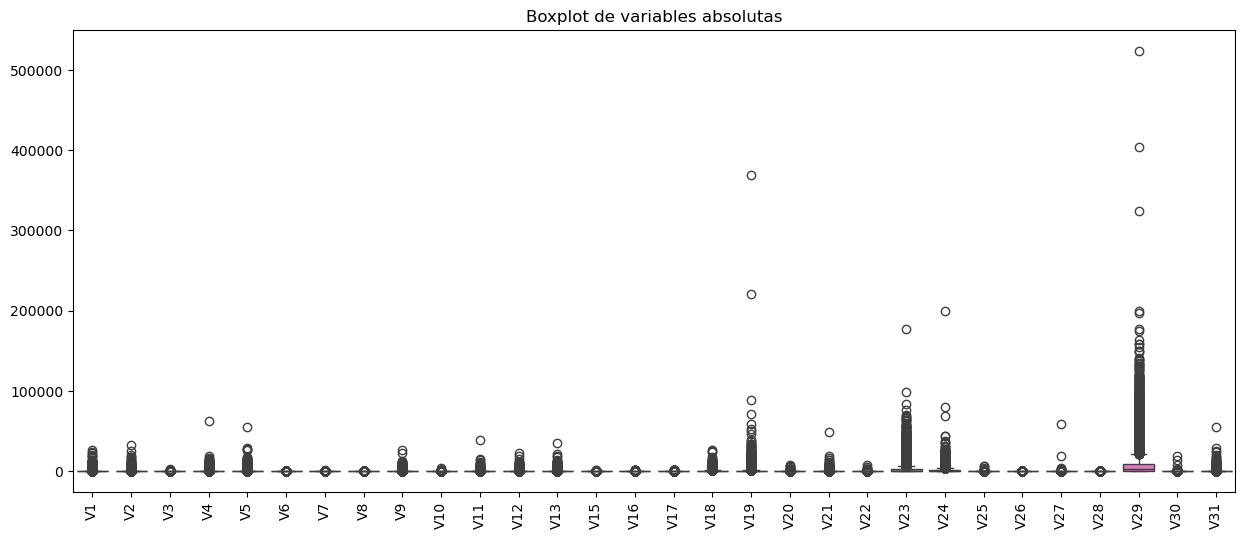

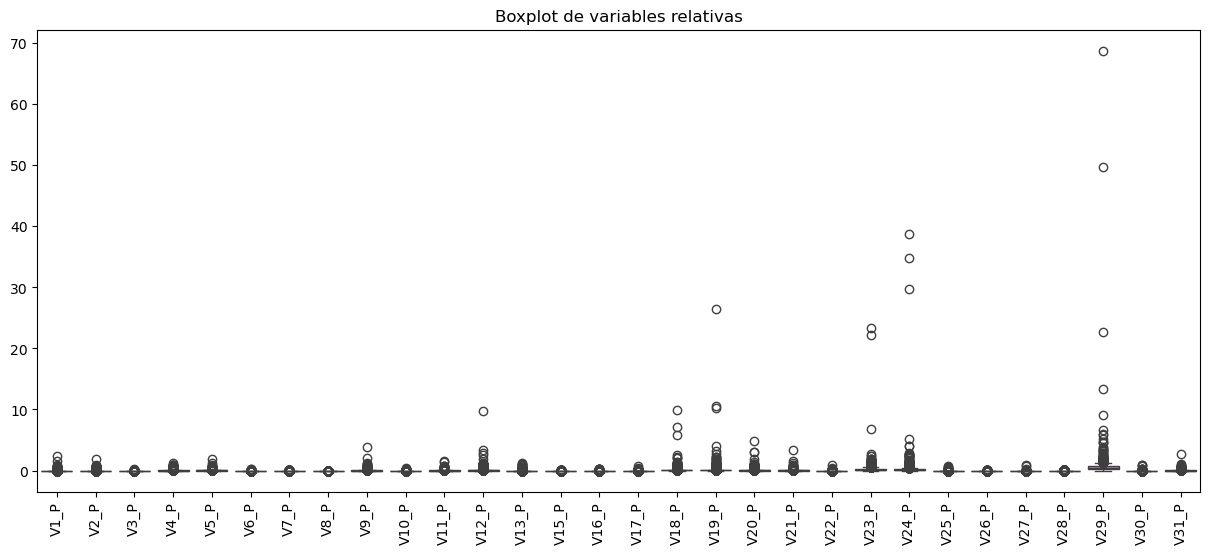

In [31]:
plot_boxplot(data, columnas_absolutas, titulo='Boxplot de variables absolutas')
plot_boxplot(data, columnas_relativas, titulo='Boxplot de variables relativas')

OBJ
0    0.7381
1    0.2619
Name: proportion, dtype: float64


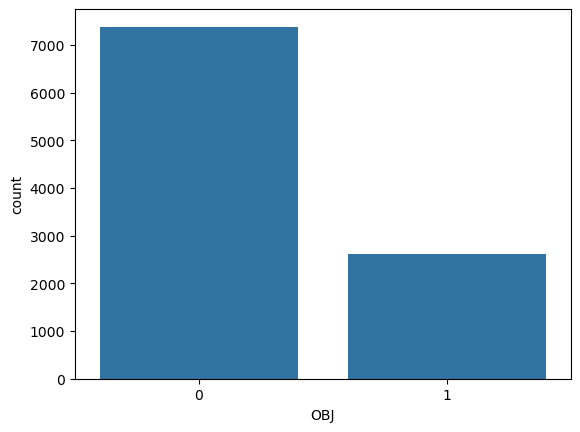

In [32]:
print(data['OBJ'].value_counts(normalize=True))  # distribución
sns.countplot(x='OBJ', data=data)
plt.show()
#tenemos una desproporcion en la distribucion de la variable objetivo

## Outliers

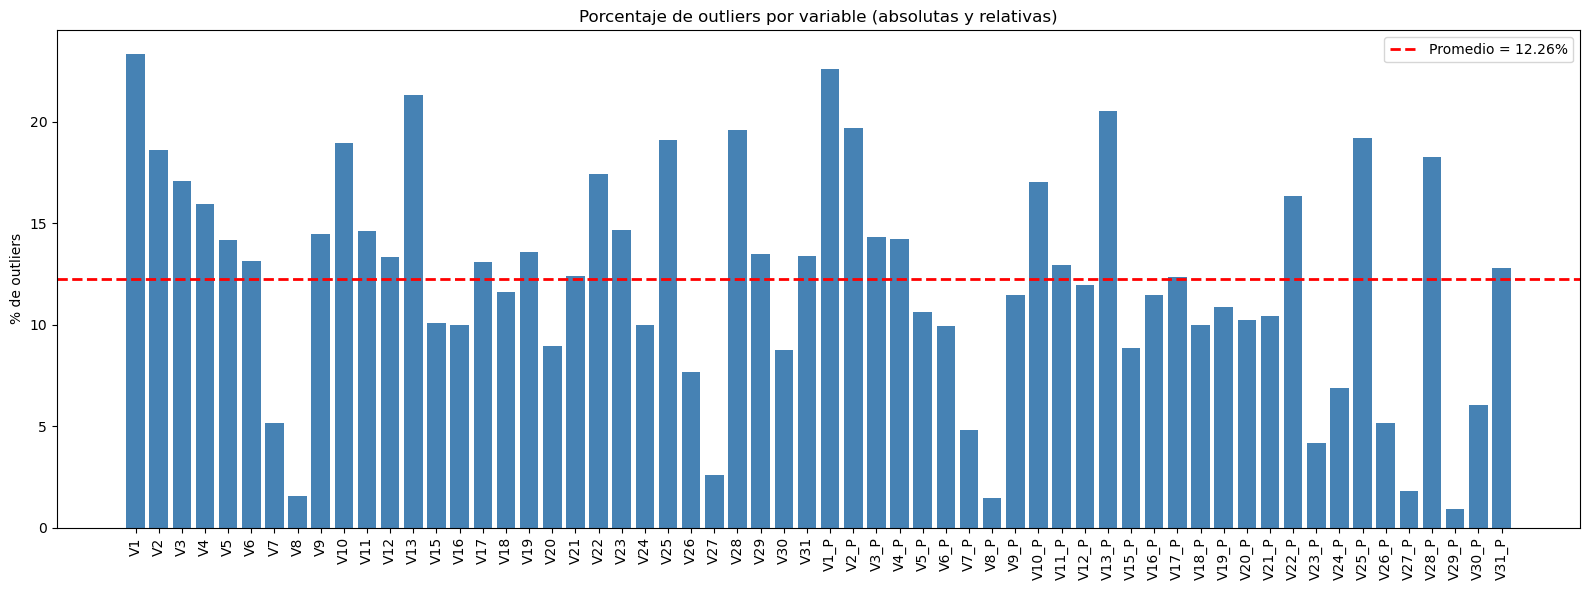

In [33]:
# Calcular promedio
df_outliers = count_outliers_iqr(data, columnas_absolutas+columnas_relativas)
mean_outliers_percent = df_outliers['outliers_percent'].mean()

plt.figure(figsize=(16,6))
plt.bar(df_outliers['variable'], df_outliers['outliers_percent'], color='steelblue')
plt.axhline(mean_outliers_percent, color='red', linestyle='--', linewidth=2, label=f'Promedio = {mean_outliers_percent:.2f}%')
plt.xticks(rotation=90)
plt.ylabel('% de outliers')
plt.title('Porcentaje de outliers por variable (absolutas y relativas)')
plt.legend()
plt.tight_layout()
plt.show()


El análisis del porcentaje de outliers por variable muestra que, en promedio, aproximadamente el 12% de los datos son considerados atípicos, aunque con una alta variabilidad entre variables. Algunas presentan porcentajes significativamente superiores (superando el 20%), mientras que otras se mantienen por debajo del 5%. Este comportamiento indica que la presencia de outliers no es homogénea en el conjunto de variables, tanto absolutas como relativas, sugiriendo la necesidad de aplicar estrategias de tratamiento diferenciadas o utilizar modelos que sean intrínsecamente robustos frente a valores extremos.

En síntesis, el perfil de outliers del dataset refleja un grado importante de dispersión, lo que deberá ser tomadp en cuenta en la etapa de preprocesamiento y modelado para evitar sesgos o sobreajustes, garantizando así un aprendizaje más confiable.

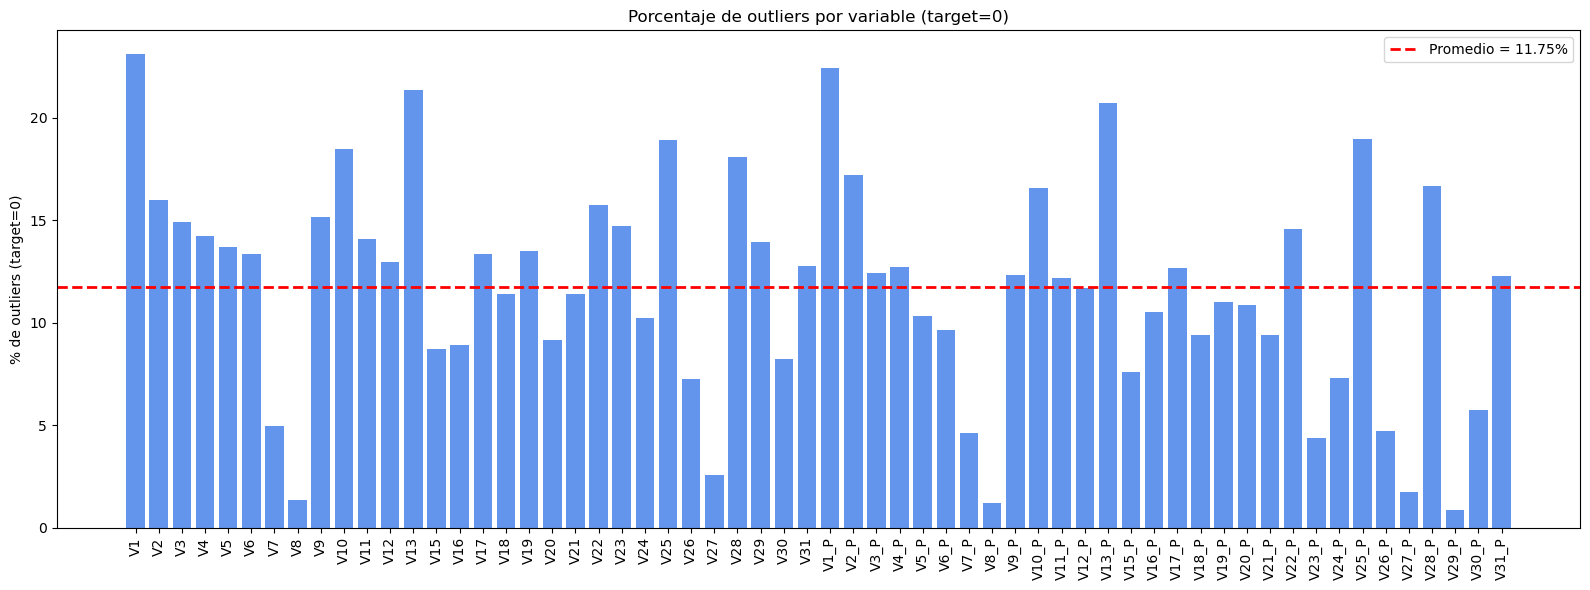

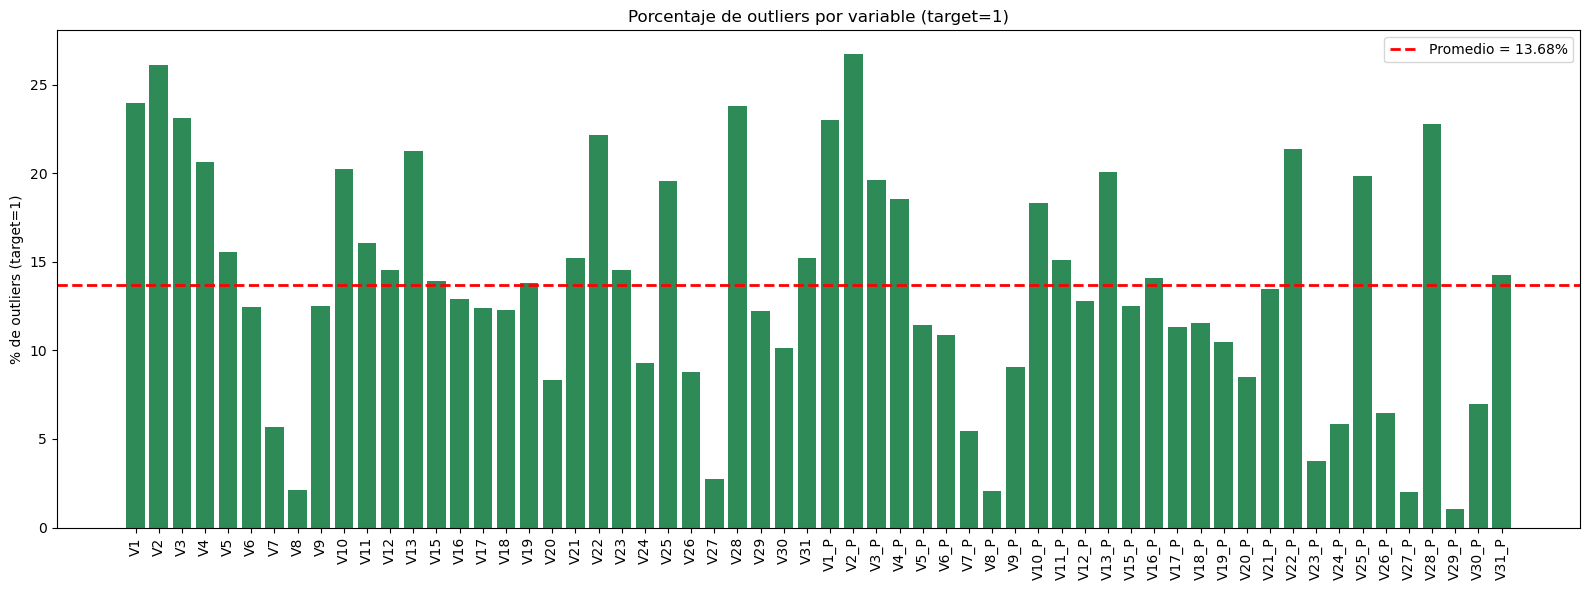

In [34]:
df_outliers_target = outlier_proportion_by_target(
    df=data,
    columns=columnas_absolutas + columnas_relativas,
    target='OBJ',
    factor=1.5
)


mean_0 = df_outliers_target['outliers_%_target_0'].mean()

plt.figure(figsize=(16,6))
plt.bar(df_outliers_target['variable'], df_outliers_target['outliers_%_target_0'], color='cornflowerblue')
plt.axhline(mean_0, color='red', linestyle='--', linewidth=2, label=f'Promedio = {mean_0:.2f}%')
plt.xticks(rotation=90)
plt.ylabel('% de outliers (target=0)')
plt.title('Porcentaje de outliers por variable (target=0)')
plt.legend()
plt.tight_layout()
plt.show()

mean_1 = df_outliers_target['outliers_%_target_1'].mean()

plt.figure(figsize=(16,6))
plt.bar(df_outliers_target['variable'], df_outliers_target['outliers_%_target_1'], color='seagreen')
plt.axhline(mean_1, color='red', linestyle='--', linewidth=2, label=f'Promedio = {mean_1:.2f}%')
plt.xticks(rotation=90)
plt.ylabel('% de outliers (target=1)')
plt.title('Porcentaje de outliers por variable (target=1)')
plt.legend()
plt.tight_layout()
plt.show()




Aunque el análisis muestra que el grupo con target = 1 tiene en promedio un 13.7% de outliers frente al 11.8% del grupo con target = 0, esta diferencia no es drásticamente significativa. Esto indica que, si bien existe una ligera mayor proporción de valores atípicos en la clase positiva, no parece un patrón lo suficientemente pronunciado como para, por sí solo, justificar un tratamiento diferencial agresivo de outliers entre las clases.

No se limpiaran los outliers dado que estan presentes en gran medida en todo el dataset en consecuencia tendriamos mucha perdida de informacion, veremos como se comporta con modelos mas complejos y  en ultimo caso intentar con tratamiento de outliers para ver si el modelo se comporta mejor.

 # Feature selection (test chi² , punto biserial,VIF y colinealidad)

## Test Chi² con transformación de variables independientes continuas a categoricas (Quartiles)

In [35]:
variables = columnas_absolutas + columnas_relativas
chi_abs_sign, chi_abs_no_sign, chi_abs_no_testable = chi2_analysis(data, columnas_absolutas, target='OBJ')
chi_rel_sign, chi_rel_no_sign, chi_rel_no_testable = chi2_analysis(data, columnas_relativas, target='OBJ')




✅ Variables significativas (p < 0.05):
['V2', 'V4', 'V5', 'V6', 'V9', 'V11', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V29', 'V31']

❌ Variables no significativas (p ≥ 0.05):
['V1']

⚠️ Variables no testables ni con ajuste (1 bin persistente):
['V3', 'V7', 'V8', 'V10', 'V15', 'V26', 'V27', 'V28', 'V30']

✅ Variables significativas (p < 0.05):
['V2_P', 'V4_P', 'V5_P', 'V6_P', 'V9_P', 'V11_P', 'V12_P', 'V13_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V29_P', 'V31_P']

❌ Variables no significativas (p ≥ 0.05):
['V1_P']

⚠️ Variables no testables ni con ajuste (1 bin persistente):
['V3_P', 'V7_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P']


Se aplicó un test de independencia Chi² categorizando cada variable en cuartiles (Q1-Q4), luego de un preprocesamiento con winsorizing (1%-99%) recortando explicitamente los valores extremos y transformacion logaritmica para reducir la asimetría mejorando la distribución.

Del total de variables analizadas:

39 variables resultaron significativas (p < 0.05), mostrando evidencia estadística de asociación con el target OBJ. Estas incluyen tanto variables absolutas como relativas, por ejemplo: V2, V4, V5, V6, V9, V11, V12, V13, V16, V17 y sus equivalentes proporcionales (V2_P, V4_P, ...).

20 variables fueron consideradas no significativas, ya sea por no superar el umbral estadístico o por carecer de suficiente variación para segmentarse en múltiples bins (solo 1 bin tras qcut). Ejemplos: V3, V7, V8, V27, V28, V30 y sus proporciones.

En resumen, este análisis permitió depurar el conjunto de variables, enfocando el modelado posterior en aquellas que demuestran un comportamiento diferenciado entre clases.

## Test Chi² con transformación de variables independientes continuas a categoricas mediante codificación binaria

In [36]:
#test chi² con codificacion binaria para variables absolutas y relativas
sig_bin_abs, nosig_bin_abs = chi2_binary_encoding_analysis(data.copy(), chi_abs_no_testable, target='OBJ')
#
sig_bin_rel, nosig_bin_rel = chi2_binary_encoding_analysis(data.copy(), chi_rel_no_testable, target='OBJ')

chi_abs_sign=chi_abs_sign + sig_bin_abs
chi_abs_no_sign=chi_abs_no_sign + nosig_bin_abs
chi_rel_sign=chi_rel_sign + sig_bin_rel
chi_rel_no_sign=chi_rel_no_sign + nosig_bin_rel


✅ Variables con codificación binaria significativas (p < 0.05):
['V3', 'V8', 'V15', 'V26', 'V28', 'V30']

❌ Variables con codificación binaria no significativas:
['V7', 'V10', 'V27']

✅ Variables con codificación binaria significativas (p < 0.05):
['V3_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V28_P', 'V30_P']

❌ Variables con codificación binaria no significativas:
['V7_P', 'V27_P']


## Punto Biseral

In [53]:
pb_abs_sign, pb_abs_no_sign = point_biserial_analysis(data, columnas_absolutas, target='OBJ')
pb_rel_sign, pb_rel_no_sign = point_biserial_analysis(data, columnas_relativas, target='OBJ')




❌ Variables excluidas por no tener varianza:
[]

✅ Variables que pasaron a validación punto biserial:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31']

❌ Variables excluidas por no tener varianza:
[]

✅ Variables que pasaron a validación punto biserial:
['V1_P', 'V2_P', 'V3_P', 'V4_P', 'V5_P', 'V6_P', 'V7_P', 'V8_P', 'V9_P', 'V10_P', 'V11_P', 'V12_P', 'V13_P', 'V15_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V26_P', 'V27_P', 'V28_P', 'V29_P', 'V30_P', 'V31_P']


## VIF

In [38]:
vif_abs_sign, vif_abs_no_sign = vif_analysis_simple(data, columnas_absolutas)
vif_rel_sign, vif_rel_no_sign = vif_analysis_simple(data, columnas_relativas)



✅ Variables con VIF < 5 (sin multicolinealidad):
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31']

❌ Variables con VIF ≥ 5 (multicolineales):
[]

✅ Variables con VIF < 5 (sin multicolinealidad):
['V1_P', 'V2_P', 'V3_P', 'V4_P', 'V5_P', 'V6_P', 'V7_P', 'V8_P', 'V9_P', 'V10_P', 'V11_P', 'V12_P', 'V13_P', 'V15_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V26_P', 'V27_P', 'V28_P', 'V29_P', 'V30_P', 'V31_P']

❌ Variables con VIF ≥ 5 (multicolineales):
[]


## Correlación

In [39]:
corr_abs_sign, corr_abs_no_sign = correlation_analysis_simple(data, columnas_absolutas, threshold=0.9)
corr_rel_sign, corr_rel_no_sign = correlation_analysis_simple(data, columnas_relativas, threshold=0.9)



✅ Variables con correlación máxima < 0.9:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31']

❌ Variables con correlación máxima ≥ 0.9:
[]

✅ Variables con correlación máxima < 0.9:
['V1_P', 'V2_P', 'V3_P', 'V4_P', 'V5_P', 'V6_P', 'V7_P', 'V8_P', 'V9_P', 'V10_P', 'V11_P', 'V12_P', 'V13_P', 'V15_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V26_P', 'V27_P', 'V28_P', 'V29_P', 'V30_P', 'V31_P']

❌ Variables con correlación máxima ≥ 0.9:
[]


## Intersección de variables

In [40]:
subset_absolutas = list(set(chi_abs_sign) & set(pb_abs_sign) & set(vif_abs_sign) & set(corr_abs_sign))
subset_relativas = list(set(chi_rel_sign) & set(pb_rel_sign) & set(vif_rel_sign) & set(corr_rel_sign))



<Figure size 1000x600 with 0 Axes>

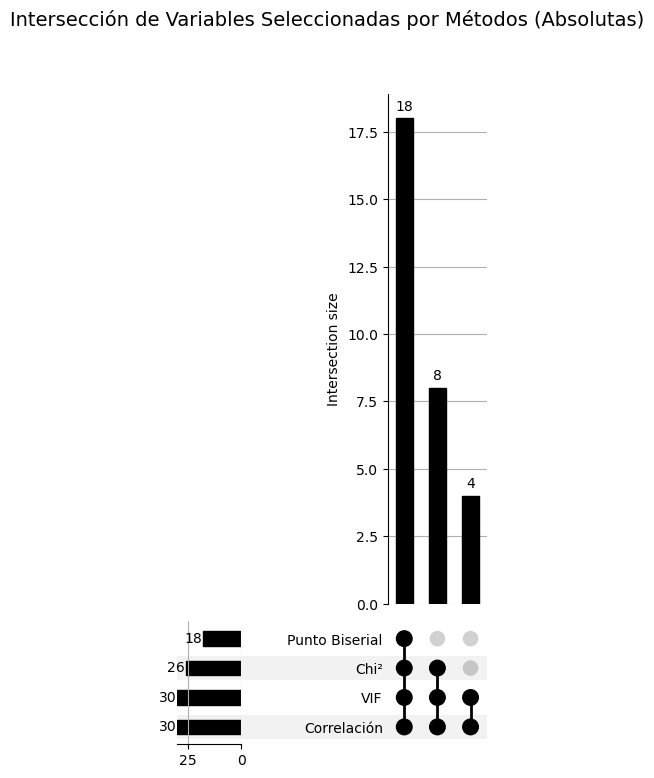

<Figure size 1000x600 with 0 Axes>

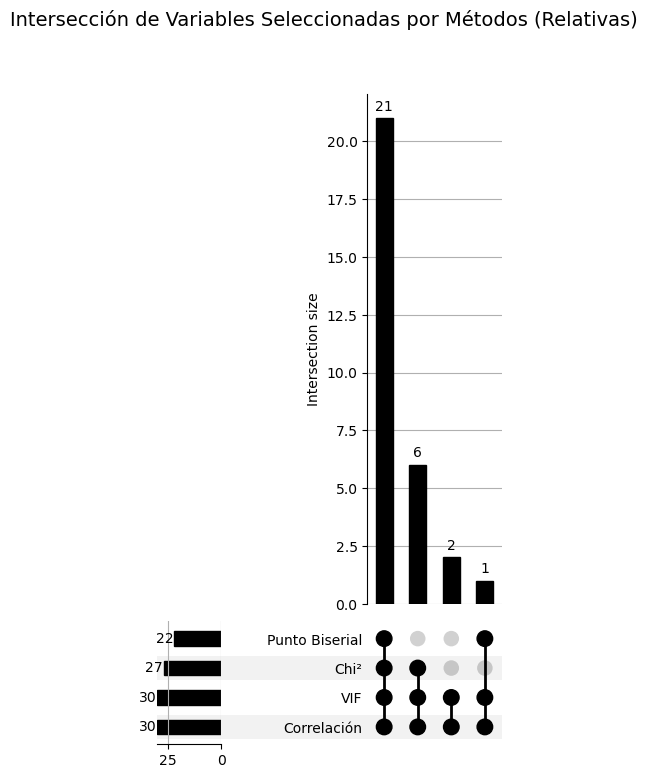

In [41]:
variable_dict = {
    "Chi²": chi_abs_sign,
    "Punto Biserial": pb_abs_sign,
    "VIF": vif_abs_sign,
    "Correlación": corr_abs_sign
}

plot_upset_variable_selection(variable_dict, title="Intersección de Variables Seleccionadas por Métodos (Absolutas)")
variable_dict_rel = {
    "Chi²": chi_rel_sign,
    "Punto Biserial": pb_rel_sign,
    "VIF": vif_rel_sign,
    "Correlación": corr_rel_sign
}
plot_upset_variable_selection(variable_dict_rel, title="Intersección de Variables Seleccionadas por Métodos (Relativas)")

## Criterio final para selección de variables

Para asegurar un subconjunto robusto de variables predictoras, se aplicaron **cuatro pruebas complementarias** de validación estadística y técnica por separado para variables absolutas y relativas:

- **Test Chi²** (asociación con variable objetivo)  
- **Coeficiente de punto biserial** (correlación con variable binaria)  
- **Factor de inflación de la varianza (VIF)** (detección de multicolinealidad)  
- **Análisis de correlación** (máxima correlación cruzada entre variables)

Solo se conservaron aquellas variables que **pasaron todos los tests**. Es decir, el criterio final de selección se basó en la **intersección de variables significativas** en los cuatro enfoques, garantizando:

- Relevancia estadística con la variable objetivo  
- No redundancia por alta colinealidad  
- Comportamiento adecuado en escalas y distribuciones (previo *winsorizing* y transformaciones)



In [42]:
# Todas las variables consideradas en cada grupo
all_abs_vars = set(chi_abs_sign + pb_abs_sign + vif_abs_sign + corr_abs_sign)
all_rel_vars = set(chi_rel_sign + pb_rel_sign + vif_rel_sign + corr_rel_sign)

# Subsets finales (pasaron todos los tests)
subset_absolutas = set(chi_abs_sign) & set(pb_abs_sign) & set(vif_abs_sign) & set(corr_abs_sign)
subset_relativas = set(chi_rel_sign) & set(pb_rel_sign) & set(vif_rel_sign) & set(corr_rel_sign)

# Variables eliminadas (no pasaron los 4 filtros)
eliminadas_abs = sorted(list(all_abs_vars - subset_absolutas))
eliminadas_rel = sorted(list(all_rel_vars - subset_relativas))

# Mostrar resultados
print("❌ Variables absolutas eliminadas:")
print(eliminadas_abs)
print("\n❌ Variables relativas eliminadas:")
print(eliminadas_rel)


❌ Variables absolutas eliminadas:
['V1', 'V10', 'V11', 'V17', 'V20', 'V23', 'V27', 'V29', 'V30', 'V31', 'V6', 'V7']

❌ Variables relativas eliminadas:
['V10_P', 'V12_P', 'V17_P', 'V19_P', 'V1_P', 'V20_P', 'V27_P', 'V29_P', 'V7_P']


# Declarar variables con las que se va trabajar

In [43]:

transformed_data = transform_logip1(data, columnas_absolutas + columnas_relativas)
y=transformed_data['OBJ']  # Variable objetivo
x= transformed_data.drop(columns=['OBJ'])
## Dividir en train/test
x_train_org,x_test_org,y_train_org,y_test_org=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables

# =====================================
# DATA ABSOLUTA
X_abs = transformed_data[columnas_absolutas]
# =====================================
# DATA ABSOLUTA FILTRADA
X_abs_filtered = X_abs.drop(columns=list(set(eliminadas_abs)))
# Dividir en train/test
X_abs_train, X_abs_test, y_abs_train, y_abs_test = train_test_split(
    X_abs, y, test_size=0.2, stratify=y, random_state=42
)
X_abs_f_train, X_abs_f_test, y_abs_f_train, y_abs_f_test = train_test_split(
    X_abs_filtered, y, test_size=0.2, stratify=y, random_state=42
)
# =====================================
# DATA RELATIVA
X_p = transformed_data[columnas_relativas]
# DATA FILTRADA
X_p_filtered = X_p.drop(columns=list(set(eliminadas_rel)))
# Dividir en train/test
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y, test_size=0.2, stratify=y, random_state=42
)
X_p_f_train, X_p_f_test, y_p_f_train, y_p_f_test = train_test_split(
    X_p_filtered, y, test_size=0.2, stratify=y, random_state=42
)


# Selección del dataset

Se evaluaron cinco versiones de datasets (`ORIG`, `ABS ORIG`, `ABS FILT`, `PROP ORIG`, `PROP FILT`) utilizando un modelo base (`Logistic Regression + RobustScaler`) bajo validación cruzada con múltiples métricas:

- **Métricas comparadas**: `accuracy`, `balanced_accuracy`, `roc_auc`, `average_precision`, `f1`, `f1_macro`, `precision`, `recall`, `matthews_corrcoef`, `neg_brier_score`, además de métricas desglosadas por clase.

---

### ✅ Argumentos para elegir `ABS FILT`

1. **Mejor desempeño global en métricas clave**:
   - `accuracy`: **0.680** (la más alta)
   - `balanced_accuracy`: **0.559**
   - `precision`: **0.367**
   - `f1_macro`: **0.561**
   - `F1_0` (clase mayoritaria): **0.790**

2. **Buena base para mejorar clase minoritaria**:
   - `recall_1`: **0.298**, actualmente bajo, pero con gran **potencial de mejora**.
   - `F1_1`: **0.328**, podría aumentar significativamente si se mejora el recall.
   - Este perfil sugiere que `ABS FILT` ya controla bien los falsos positivos (alta precisión), por lo que se puede trabajar en aumentar la sensibilidad (recall) sin sacrificar demasiado rendimiento general.

3. **Distribución más limpia y consistente**:
   - Al ser una versión filtrada, se presume que tiene menos ruido y posibles outliers, lo que puede facilitar un mejor ajuste de modelos avanzados.
   - Su rendimiento es más estable que el de `ORIG` o `PROP ORIG`, y más equilibrado que `ABS ORIG`.

---

,Dataset,Mean_CV_Score_accuracy,Mean_CV_Score_roc_auc,Mean_CV_Score_average_precision,Mean_CV_Score_f1,Mean_CV_Score_f1_macro,Mean_CV_Score_balanced_accuracy,Mean_CV_Score_precision,Mean_CV_Score_recall,Mean_CV_Score_matthews_corrcoef,Mean_CV_Score_neg_brier_score,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
0,ORIG,0.618500,0.597547,0.333949,0.396694,0.558706,0.573418,0.339360,0.478759,0.134094,-0.245085,0.766008,0.656504,0.707041,0.310204,0.435115,0.362192
1,ABS ORIG,0.675750,0.595486,0.341536,0.349305,0.566672,0.565078,0.367998,0.332697,0.134551,-0.245936,0.770190,0.794715,0.782261,0.364780,0.332061,0.347652
2,ABS FILT,0.679625,0.593936,0.341207,0.333149,0.561148,0.558926,0.366531,0.305489,0.125558,-0.245852,0.766052,0.816396,0.790423,0.365340,0.297710,0.328076
3,PROP ORIG,0.603750,0.585694,0.321057,0.387404,0.547094,0.563273,0.326268,0.478282,0.114741,-0.246736,0.771774,0.648374,0.704713,0.317105,0.459924,0.375389
4,PROP FILT,0.605500,0.584939,0.321483,0.388013,0.548176,0.564304,0.327704,0.477804,0.116805,-0.246719,0.771475,0.644986,0.702583,0.315927,0.461832,0.375194


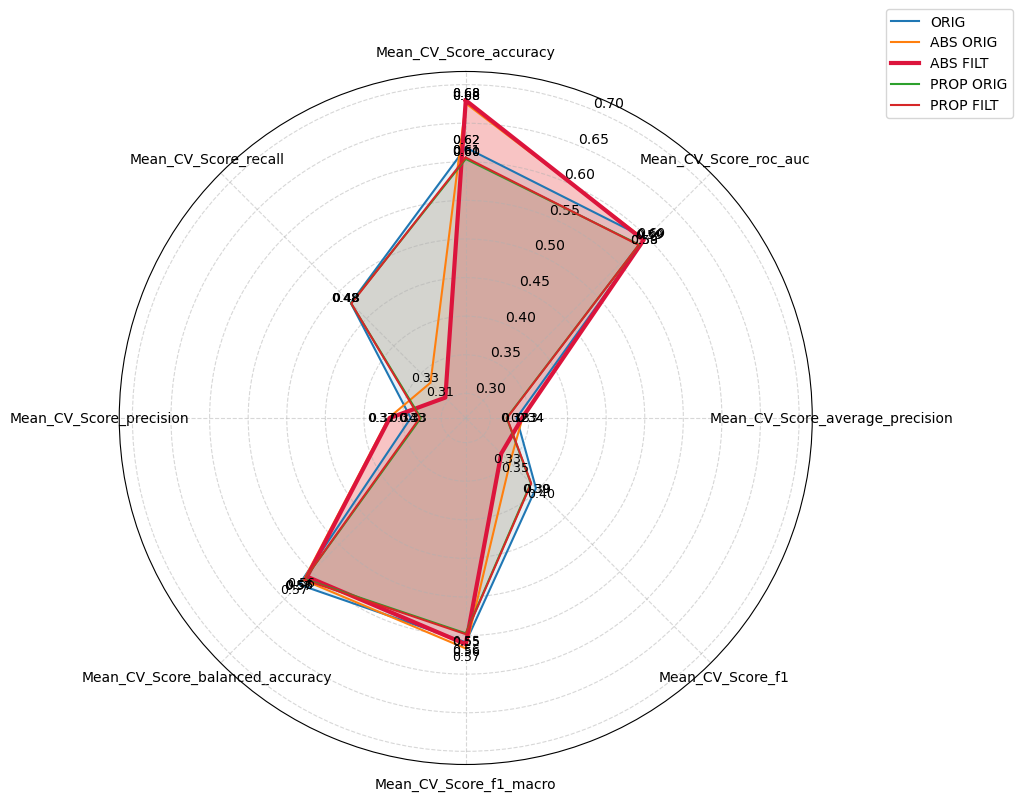

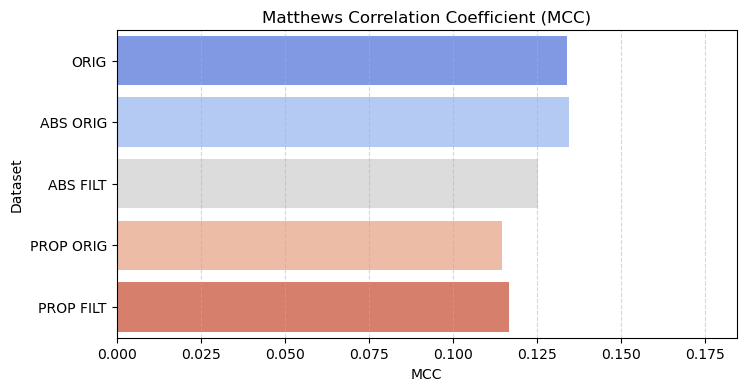

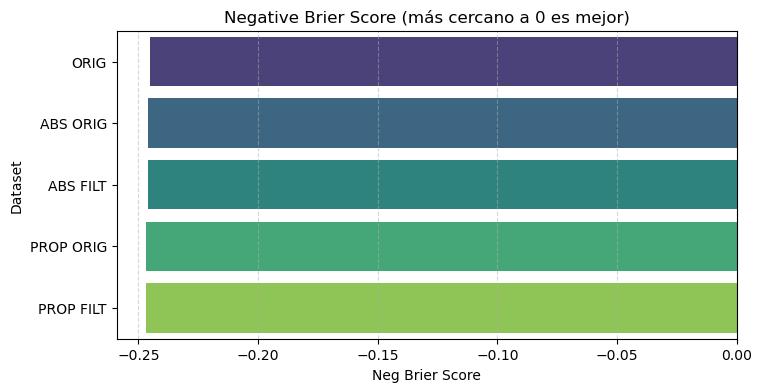

In [44]:
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# =====================================
# LISTA DE DATASETS
# =====================================
datasets = [
    ("ORIG", x_train_org, y_train_org, x_test_org, y_test_org),
    ("ABS ORIG", X_abs_train, y_abs_train, X_abs_test, y_abs_test),
    ("ABS FILT", X_abs_f_train, y_abs_f_train, X_abs_f_test, y_abs_f_test),
    ("PROP ORIG", X_p_train, y_p_train, X_p_test, y_p_test),
    ("PROP FILT", X_p_f_train, y_p_f_train, X_p_f_test, y_p_f_test)
]

# =====================================
# SCORINGS COMO COLUMNAS
# =====================================
scorings = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'f1': 'f1',
    'f1_macro': 'f1_macro',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'matthews_corrcoef': 'matthews_corrcoef',   # 
    'neg_brier_score': 'neg_brier_score'
}



# =====================================
# PIPELINE SIMPLE
# =====================================
pipe_lr = Pipeline([
    ('scaler', RobustScaler()),  # si las variables están transformadas, puede omitirse
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

# =====================================
# LOOP PRINCIPAL
# =====================================
results = []

for (dataset_name, X_train, y_train, X_test, y_test) in datasets:
    dataset_result = {'Dataset': dataset_name}
    
    # Guardar Mean_CV_Score de cada scoring
    for scoring in scorings:
        grid = GridSearchCV(pipe_lr, {}, cv=5, scoring=scoring, n_jobs=-1)
        grid.fit(X_train, y_train)
        dataset_result[f"Mean_CV_Score_{scoring}"] = grid.best_score_
    
    # Calcular métricas finales en test set
    y_pred = grid.best_estimator_.predict(X_test)
    dataset_result.update({
        'Precision_0': precision_score(y_test, y_pred, pos_label=0),
        'Recall_0': recall_score(y_test, y_pred, pos_label=0),
        'F1_0': f1_score(y_test, y_pred, pos_label=0),
        'Precision_1': precision_score(y_test, y_pred, pos_label=1),
        'Recall_1': recall_score(y_test, y_pred, pos_label=1),
        'F1_1': f1_score(y_test, y_pred, pos_label=1)
    })
    
    results.append(dataset_result)

# =====================================
# CONSOLIDAR EN DATAFRAME FINAL
# =====================================
df_dataset_results = pd.DataFrame(results)
display(df_dataset_results)



# =====================================
# FILTRAR MÉTRICAS COMPARABLES
# =====================================
excluded_metrics = ['matthews_corrcoef', 'neg_brier_score']
labels = [f'Mean_CV_Score_{scoring}' for scoring in scorings.keys() if scoring not in excluded_metrics]

# =====================================
# ANGULOS Y COORDENADAS
# =====================================
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# =====================================
# CALCULAR RANGO AUTOMÁTICO
# =====================================
all_values = df_dataset_results[labels].values.flatten()
min_val = all_values.min()
max_val = all_values.max()
padding = (max_val - min_val) * 0.1
lower = max(0, min_val - padding)
upper = min(1, max_val + padding)

# =====================================
# PLOT RADAR
# =====================================
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, row in df_dataset_results.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    dataset_name = row['Dataset']
    
    if dataset_name == 'ABS FILT':
        ax.plot(angles, values, linewidth=3, linestyle='-', label=dataset_name, color='crimson')
        ax.fill(angles, values, alpha=0.2, color='crimson')
    else:
        ax.plot(angles, values, linewidth=1.5, label=dataset_name)
        ax.fill(angles, values, alpha=0.1)
    
    for angle, val in zip(angles, values):
        ax.text(angle, val + 0.01, f"{val:.2f}", size=9, ha='center', va='center')

# Ajustes del gráfico
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(lower, upper)
plt.title("", fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# Datos a graficar
# =====================================
mcc_brier_df = df_dataset_results[['Dataset', 'Mean_CV_Score_matthews_corrcoef', 'Mean_CV_Score_neg_brier_score']].set_index('Dataset')

# ========== Barplot de MCC ==========
plt.figure(figsize=(8, 4))
sns.barplot(data=mcc_brier_df, x='Mean_CV_Score_matthews_corrcoef', y=mcc_brier_df.index, palette='coolwarm')
plt.title('Matthews Correlation Coefficient (MCC)')
plt.xlabel('MCC')
plt.ylabel('Dataset')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, max(mcc_brier_df['Mean_CV_Score_matthews_corrcoef']) + 0.05)
plt.show()

# ========== Barplot de Brier Score ==========
plt.figure(figsize=(8, 4))
sns.barplot(data=mcc_brier_df, x='Mean_CV_Score_neg_brier_score', y=mcc_brier_df.index, palette='viridis')
plt.title('Negative Brier Score (más cercano a 0 es mejor)')
plt.xlabel('Neg Brier Score')
plt.ylabel('Dataset')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()



**MCC: mide el rendimiento general, considerando todos los elementos de la matriz de confusión. Más cercano a 1 es mejor.

**Neg Brier Score: mide cuán bien calibradas están las probabilidades. Cero es lo mejor. Valores negativos más cercanos a 0 son mejores (por eso la dirección del eje es importante).

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_abs_filtered, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Base Model

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Train
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      5905
           1       0.37      0.32      0.34      2095

    accuracy                           0.68      8000
   macro avg       0.57      0.56      0.56      8000
weighted avg       0.66      0.68      0.67      8000

Test
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1476
           1       0.37      0.31      0.34       524

    accuracy                           0.68      2000
   macro avg       0.57      0.56      0.56      2000
weighted avg       0.66      0.68      0.67      2000



,Logistic Regression
Accuracy,0.680500
Balanced_Accuracy,0.560130
Precision,0.368421
Recall,0.307252
F1,0.335068
ROC_AUC,0.576645


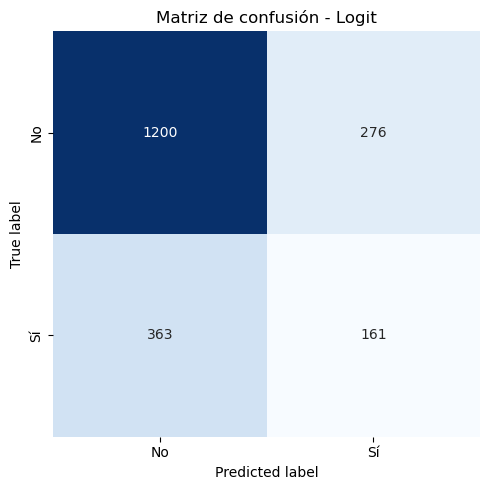

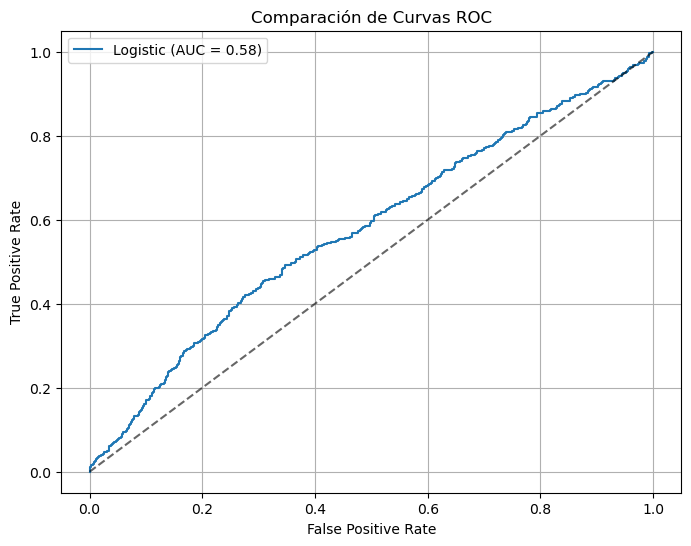

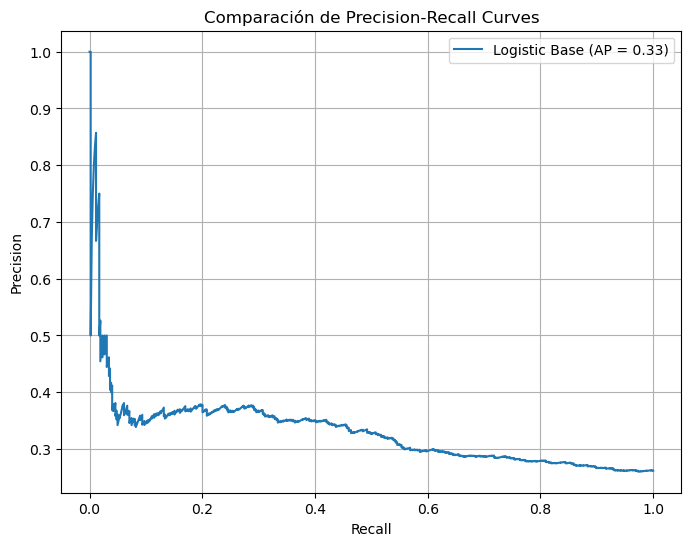

In [46]:
from sklearn.linear_model import LogisticRegression

pipe_logit_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit_base,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
base_logit = grid_logit.best_estimator_
#Predicciones Test
y_pred_train_logit = base_logit.predict(X_train)
y_proba_train_logit = base_logit.predict_proba(X_train)[:,1]

#Predicciones Test
y_pred_logit = base_logit.predict(X_test)
y_proba_logit = base_logit.predict_proba(X_test)[:,1]
cm_logit_base = confusion_matrix(y_test, y_pred_logit)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': base_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit_base,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic Base': y_proba_logit})


# Random Forest

## Base Random Forest

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Reporte en TRAIN:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5905
           1       1.00      0.98      0.99      2095

    accuracy                           0.99      8000
   macro avg       1.00      0.99      0.99      8000
weighted avg       1.00      0.99      0.99      8000

Reporte en TEST:
              precision    recall  f1-score   support

           0       0.75      0.95      0.84      1476
           1       0.45      0.12      0.19       524

    accuracy                           0.73      2000
   macro avg       0.60      0.53      0.52      2000
weighted avg       0.67      0.73      0.67      2000



,Random Forest
Accuracy,0.731000
Balanced_Accuracy,0.534646
Precision,0.450704
Recall,0.122137
F1,0.192192
ROC_AUC,0.584576


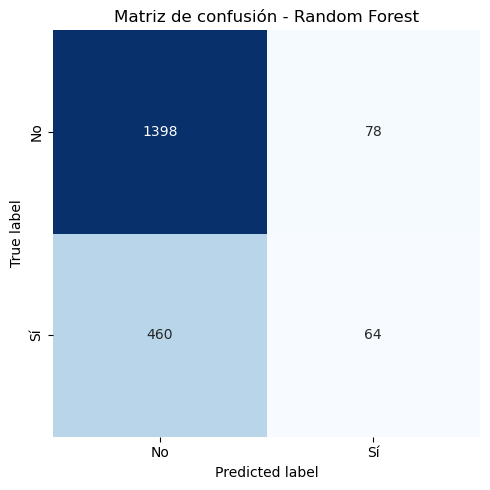

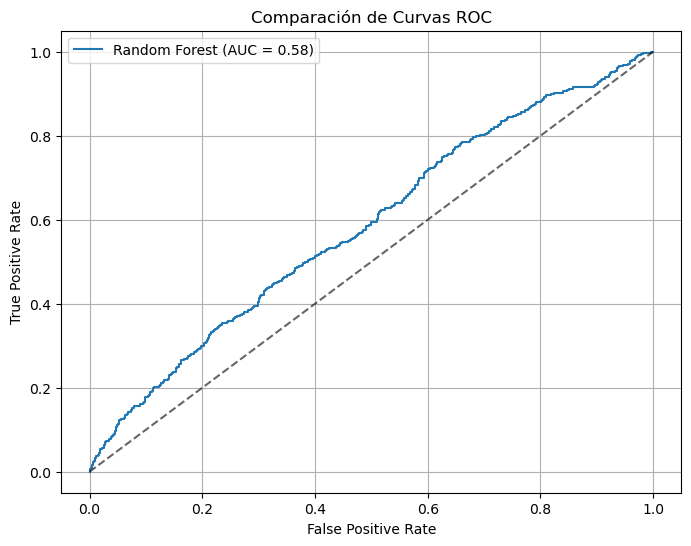

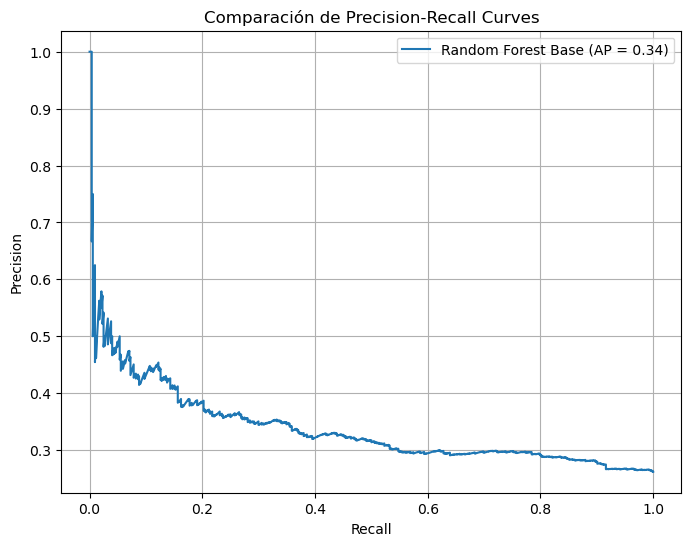

In [54]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# Pipeline RF
pipe_base_rf = Pipeline([
    

    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3]
}

grid_rf = GridSearchCV(
    estimator=pipe_base_rf,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
base_rf = grid_rf.best_estimator_
# Predicciones sobre entrenamiento
y_pred_train_rf = base_rf.predict(X_train)
y_proba_train_rf = base_rf.predict_proba(X_train)[:, 1]
# Predicciones sobre test
y_pred_base_rf = base_rf.predict(X_test)
y_proba_base_rf = base_rf.predict_proba(X_test)[:,1]
cm_base_rf = confusion_matrix(y_test, y_pred_base_rf)

print("Reporte en TRAIN:")
print(classification_report(y_train, y_pred_train_rf))
print("Reporte en TEST:")
print(classification_report(y_test, y_pred_base_rf))

display(evaluate_models({
    'Random Forest': base_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_base_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_base_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest Base': y_proba_base_rf})



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados:
{'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'scaler__n_quantiles': 3000, 'scaler__output_distribution': 'normal'}
Train
              precision    recall  f1-score   support

           0       0.89      0.54      0.67      5905
           1       0.39      0.81      0.52      2095

    accuracy                           0.61      8000
   macro avg       0.64      0.67      0.60      8000
weighted avg       0.76      0.61      0.63      8000

Test
              precision    recall  f1-score   support

           0       0.80      0.47      0.59      1476
           1       0.31      0.66      0.42       524

    accuracy                           0.52      2000
   macro avg       0.55      0.57      0.50      2000
weighted avg       0.67      0.52      0.55      2000



,Random Forest
Accuracy,0.519500
Balanced_Accuracy,0.565524
Precision,0.306808
Recall,0.662214
F1,0.419335
ROC_AUC,0.588885


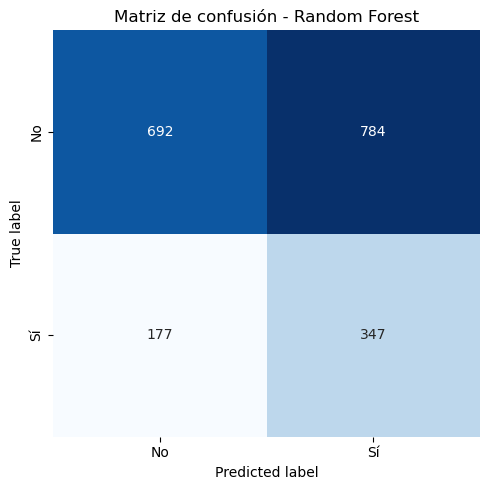

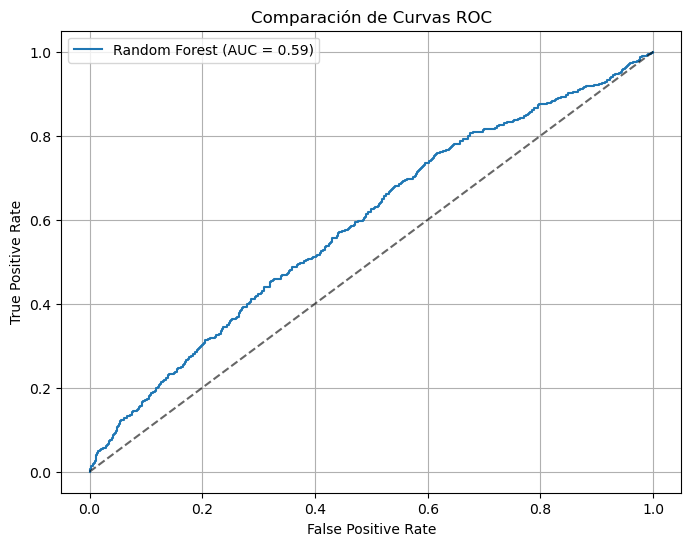

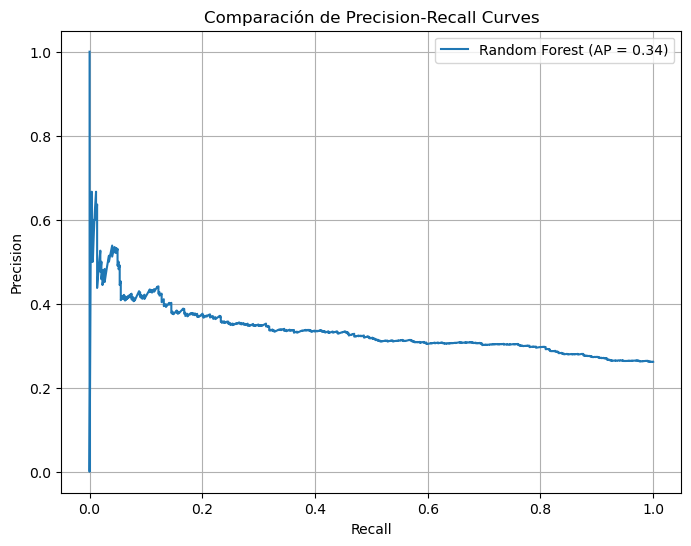

In [55]:
# Probando diferentes scalers
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'scaler__n_quantiles': [1000, 2000,3000],
    'scaler__output_distribution': ['normal', 'uniform']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_train_rf = best_rf.predict(X_train)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_rf))

print('Test')
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'model__max_depth': 20, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'sampler': SMOTEENN()}
Train
              precision    recall  f1-score   support

           0       0.90      0.59      0.71      5905
           1       0.41      0.81      0.55      2095

    accuracy                           0.65      8000
   macro avg       0.66      0.70      0.63      8000
weighted avg       0.77      0.65      0.67      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.48      0.60      1476
           1       0.31      0.65      0.42       524

    accuracy                           0.52      2000
   macro avg       0.55      0.57      0.51      2000
weighted avg       0.67      0.52      0.55      2000



,Random Forest
Accuracy,0.523500
Balanced_Accuracy,0.565157
Precision,0.307278
Recall,0.652672
F1,0.417838
ROC_AUC,0.584065


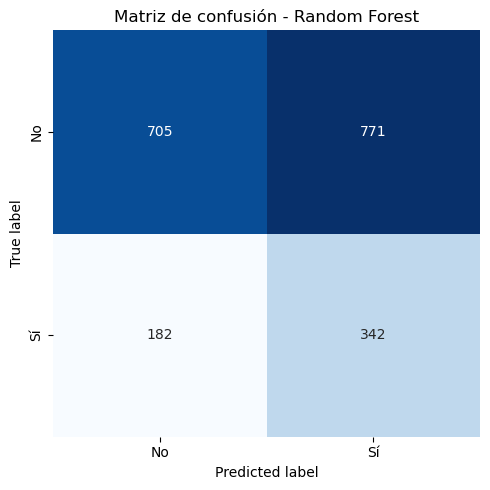

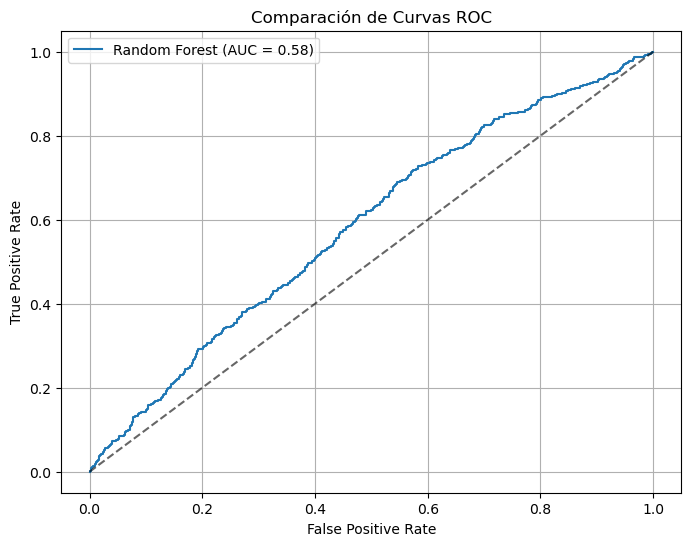

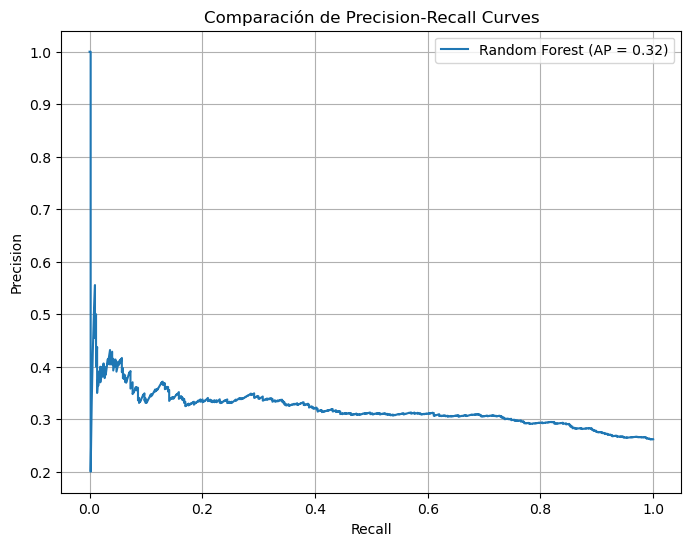

In [56]:
# Probando diferentes samplers
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'sampler': [SMOTEENN(),SMOTE(), ADASYN(), SMOTETomek(), None]

}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_train_rf = best_rf.predict(X_train)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_rf))

print('Test')
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'model__max_depth': 20, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'sampler': SMOTEENN(enn=EditedNearestNeighbours(),
         smote=SMOTE(k_neighbors=2, random_state=42, sampling_strategy=0.5))}
Train
              precision    recall  f1-score   support

           0       0.98      0.65      0.78      5905
           1       0.50      0.97      0.66      2095

    accuracy                           0.74      8000
   macro avg       0.74      0.81      0.72      8000
weighted avg       0.86      0.74      0.75      8000

Test
              precision    recall  f1-score   support

           0       0.78      0.50      0.61      1476
           1       0.30      0.61      0.41       524

    accuracy                           0.53      2000
   macro avg       0.54      0.56      0.51      2000
weighted avg       0.66      0.53      0.56      2000

,Random Forest
Accuracy,0.530500
Balanced_Accuracy,0.556360
Precision,0.303318
Recall,0.610687
F1,0.405320
ROC_AUC,0.580149


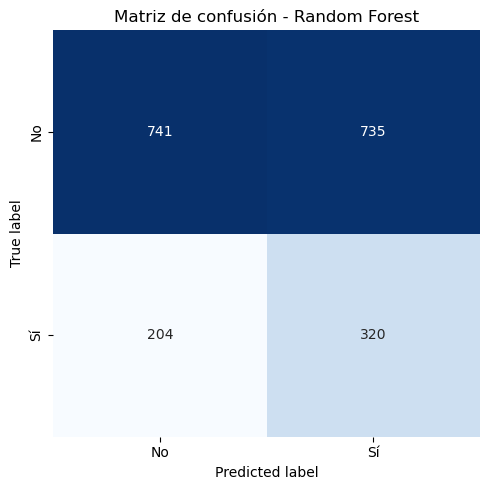

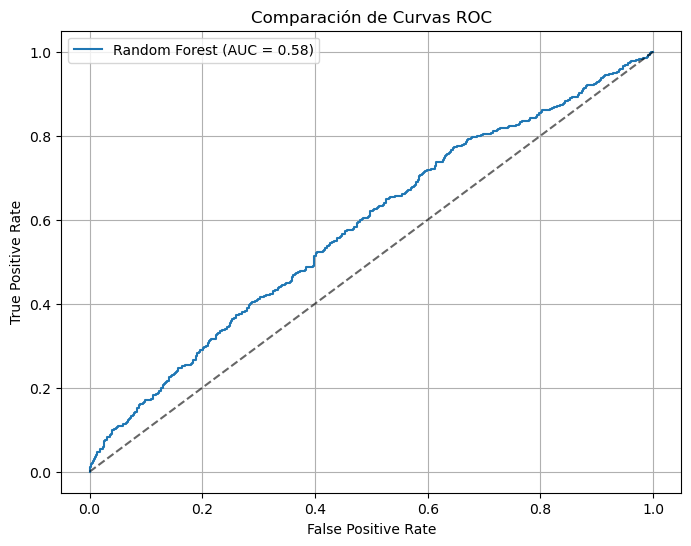

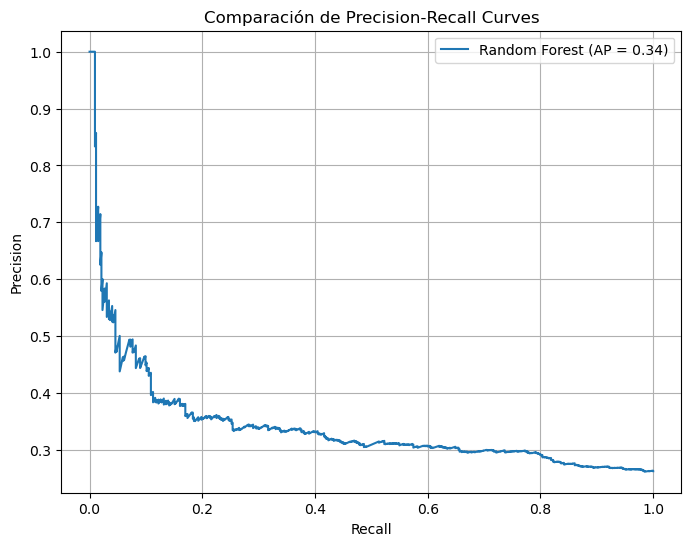

In [57]:
# ajustando SMOTENN
from imblearn.under_sampling import EditedNearestNeighbours
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'sampler': [
        SMOTEENN(smote=SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=42), 
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=3, sampling_strategy=0.7, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=3, sampling_strategy=0.5, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=5)),
        SMOTEENN(smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=5)),
    ]

}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_train_rf = best_rf.predict(X_train)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_rf))

print('Test')
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

## Random Forest Modelo Ajustado

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Mejores parámetros encontrados:
{'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Train
              precision    recall  f1-score   support

           0       0.89      0.59      0.71      5905
           1       0.41      0.80      0.54      2095

    accuracy                           0.65      8000
   macro avg       0.65      0.70      0.63      8000
weighted avg       0.77      0.65      0.67      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.53      0.63      1476
           1       0.32      0.62      0.42       524

    accuracy                           0.55      2000
   macro avg       0.55      0.57      0.52      2000
weighted avg       0.67      0.55      0.58      2000



,Random Forest
Accuracy,0.549000
Balanced_Accuracy,0.570740
Precision,0.315430
Recall,0.616412
F1,0.417313
ROC_AUC,0.594271


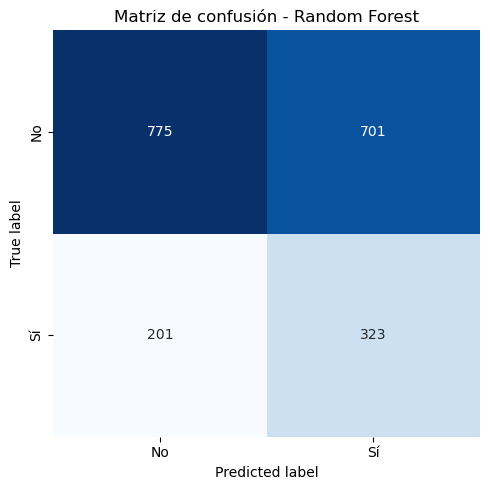

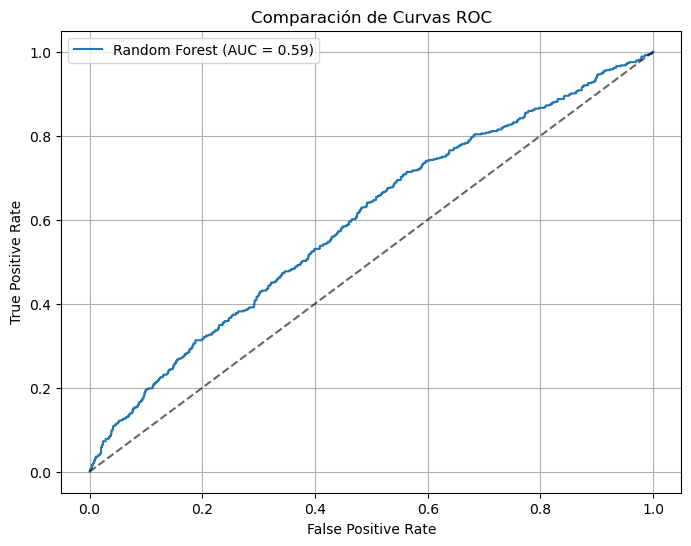

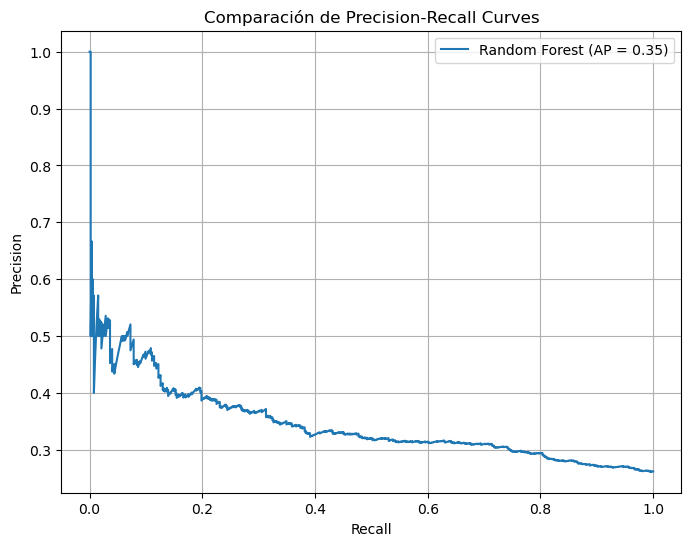

In [58]:
# ajustando parametros del modelo
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import SMOTE

pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN(enn=EditedNearestNeighbours(),smote=SMOTE(k_neighbors=2, random_state=42, sampling_strategy=0.5))),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200,300],
    'model__max_depth': [8, 10, 12, 15],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [1,2,3,4],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']


 
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_train_rf = best_rf.predict(X_train)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_rf))

print('Test')
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

modelo ajustado para random forest

# Logistic Regression

## Modelo Base Logistic Regresion

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Train
              precision    recall  f1-score   support

           0       0.81      0.50      0.62      5905
           1       0.32      0.67      0.43      2095

    accuracy                           0.54      8000
   macro avg       0.56      0.58      0.52      8000
weighted avg       0.68      0.54      0.57      8000

Test
              precision    recall  f1-score   support

           0       0.78      0.50      0.61      1476
           1       0.30      0.61      0.41       524

    accuracy                           0.53      2000
   macro avg       0.54      0.56      0.51      2000
weighted avg       0.66      0.53      0.56      2000



,Logistic Regression
Accuracy,0.530500
Balanced_Accuracy,0.556975
Precision,0.303690
Recall,0.612595
F1,0.406072
ROC_AUC,0.587777


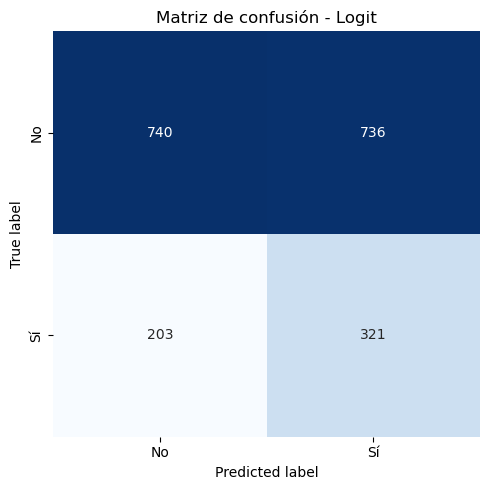

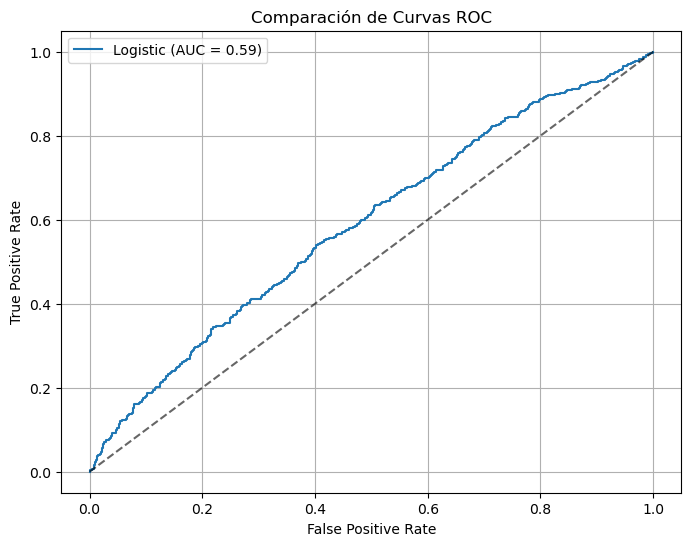

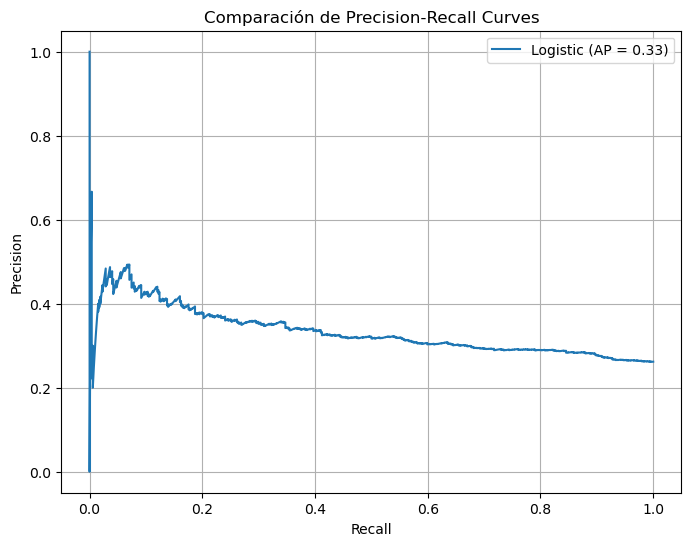

In [59]:
from sklearn.linear_model import LogisticRegression

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Train
              precision    recall  f1-score   support

           0       0.80      0.50      0.62      5905
           1       0.32      0.65      0.43      2095

    accuracy                           0.54      8000
   macro avg       0.56      0.58      0.52      8000
weighted avg       0.68      0.54      0.57      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1476
           1       0.31      0.62      0.41       524

    accuracy                           0.54      2000
   macro avg       0.55      0.57      0.52      2000
weighted avg       0.67      0.54      0.57      2000



,Logistic Regression
Accuracy,0.540000
Balanced_Accuracy,0.565873
Precision,0.310707
Recall,0.620229
F1,0.414013
ROC_AUC,0.589437


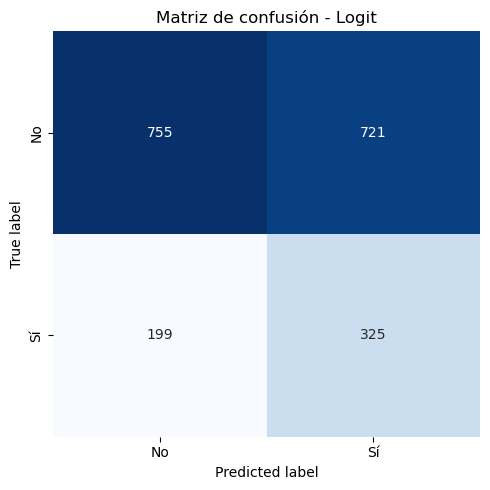

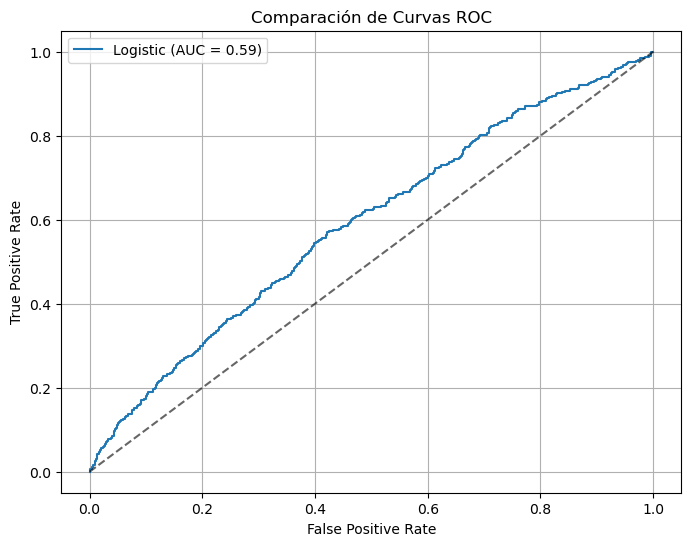

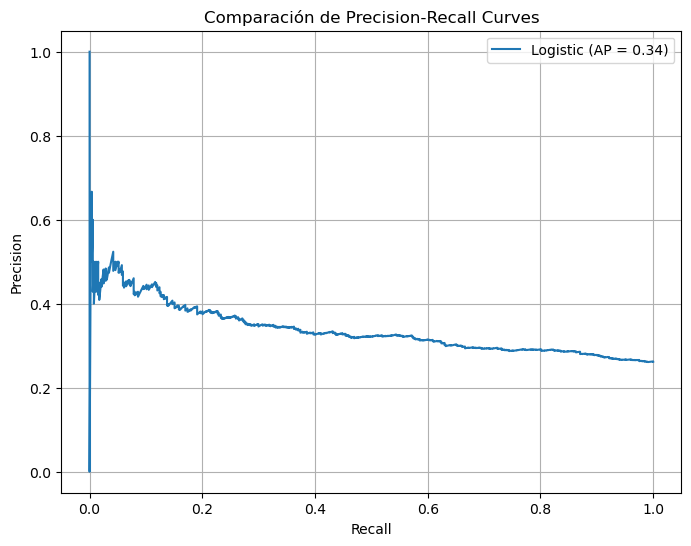

In [60]:
#cambiando a scoring f1
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
    
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})



Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores parámetros encontrados:
{'model__C': 0.01, 'model__penalty': 'l2'}
Train
              precision    recall  f1-score   support

           0       0.81      0.51      0.62      5905
           1       0.32      0.66      0.43      2095

    accuracy                           0.55      8000
   macro avg       0.56      0.58      0.53      8000
weighted avg       0.68      0.55      0.57      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.52      0.62      1476
           1       0.31      0.61      0.41       524

    accuracy                           0.54      2000
   macro avg       0.55      0.56      0.52      2000
weighted avg       0.66      0.54      0.57      2000



,Logistic Regression
Accuracy,0.540500
Balanced_Accuracy,0.563135
Precision,0.309179
Recall,0.610687
F1,0.410520
ROC_AUC,0.590823


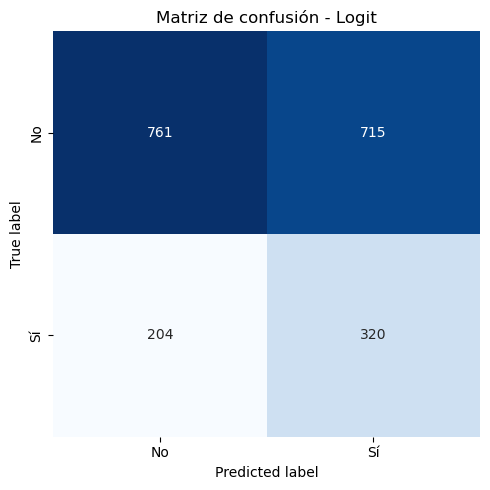

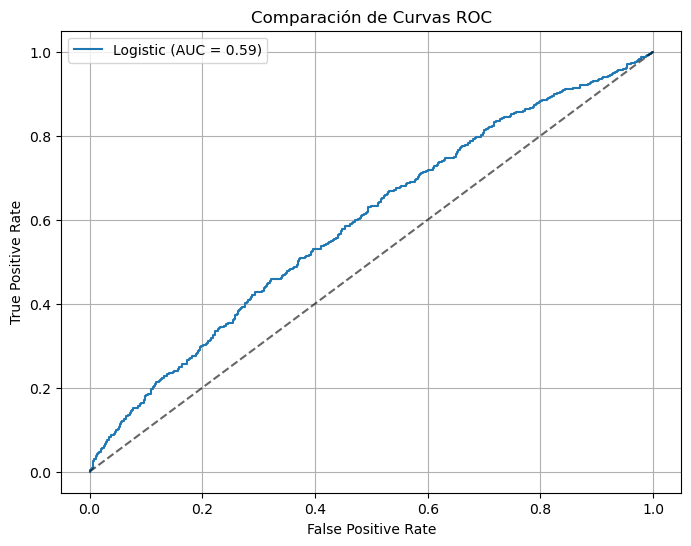

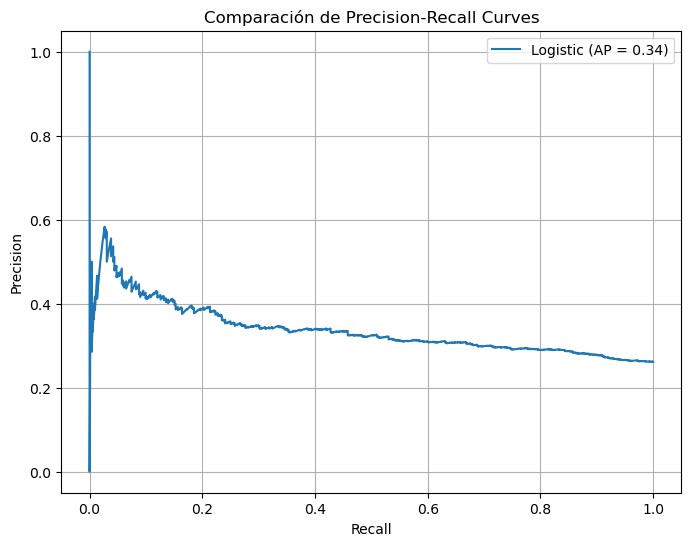

In [61]:
#cambiando a scoring precision
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

El scoring no cambió mucho el comportamiento, porque probablemente:

El sampler (SMOTEENN) + class_weight='balanced' fuerza a encontrar la clase minoritaria, inflando recall.

Eso genera muchos falsos positivos, por eso precision baja.

✅ Es decir, el scoring no hizo la diferencia porque el problema está dominado por el sampler y el sesgo del pipeline.

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados:
{'model__C': 1, 'model__penalty': 'l2', 'sampler': SMOTE(), 'scaler__n_quantiles': 3000, 'scaler__output_distribution': 'uniform'}
Train
              precision    recall  f1-score   support

           0       0.80      0.61      0.69      5905
           1       0.34      0.57      0.43      2095

    accuracy                           0.60      8000
   macro avg       0.57      0.59      0.56      8000
weighted avg       0.68      0.60      0.62      8000

Test
              precision    recall  f1-score   support

           0       0.78      0.59      0.67      1476
           1       0.32      0.54      0.40       524

    accuracy                           0.58      2000
   macro avg       0.55      0.57      0.54      2000
weighted avg       0.66      0.58      0.60      2000



,Logistic Regression
Accuracy,0.578000
Balanced_Accuracy,0.565154
Precision,0.319005
Recall,0.538168
F1,0.400568
ROC_AUC,0.593611


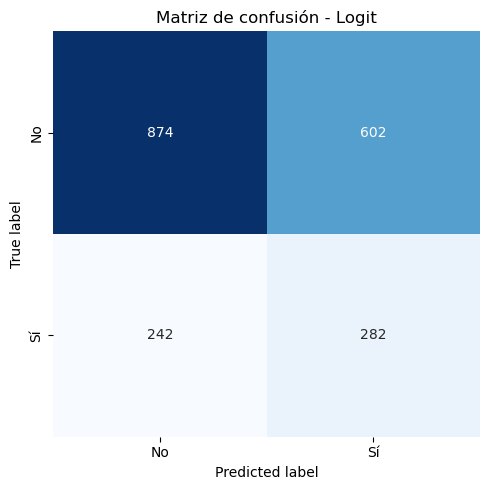

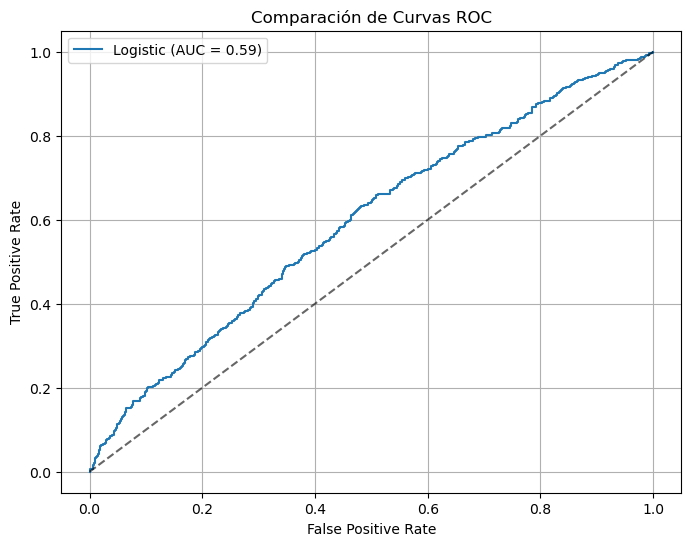

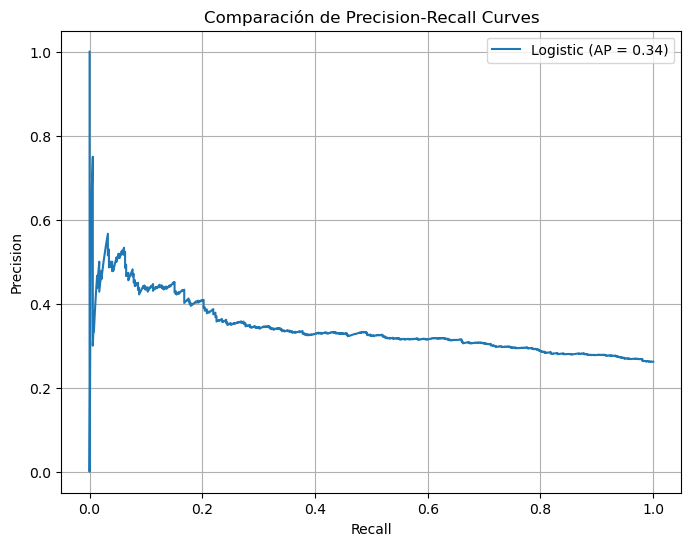

In [62]:
#probando varios grid_search
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles,
    'scaler__output_distribution': ['normal', 'uniform'],
    'sampler': [SMOTEENN(),SMOTE(), ADASYN(), SMOTETomek(), None],
   
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados:
{'model__C': 0.1, 'model__penalty': 'l1', 'sampler': SMOTETomek(smote=SMOTE(random_state=42, sampling_strategy=1.0))}
Train
              precision    recall  f1-score   support

           0       0.80      0.60      0.69      5905
           1       0.34      0.58      0.43      2095

    accuracy                           0.60      8000
   macro avg       0.57      0.59      0.56      8000
weighted avg       0.68      0.60      0.62      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.59      0.67      1476
           1       0.32      0.56      0.41       524

    accuracy                           0.58      2000
   macro avg       0.56      0.57      0.54      2000
weighted avg       0.67      0.58      0.61      2000



,Logistic Regression
Accuracy,0.580500
Balanced_Accuracy,0.573003
Precision,0.324805
Recall,0.557252
F1,0.410401
ROC_AUC,0.598356


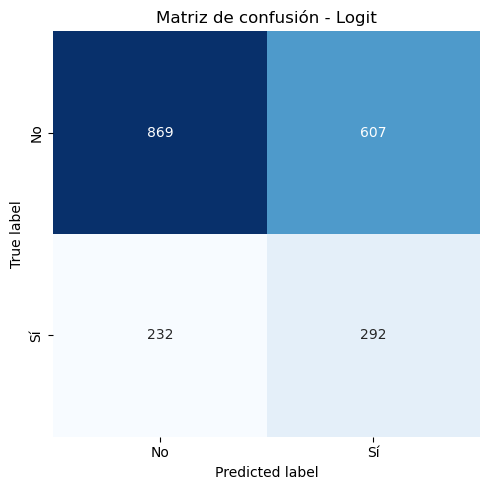

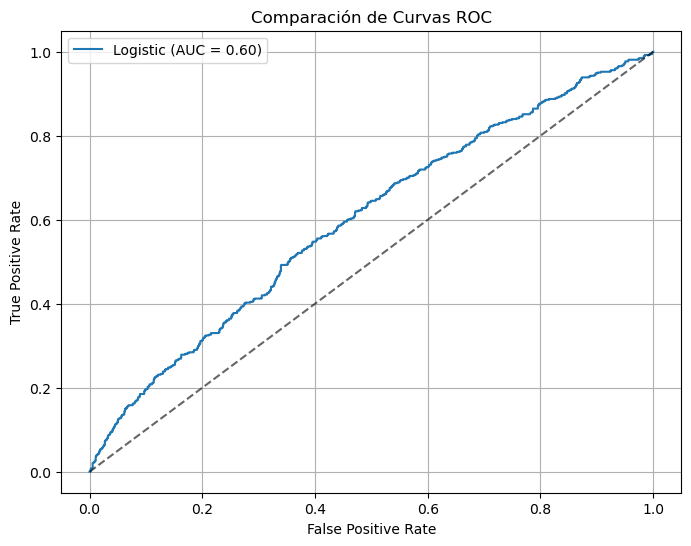

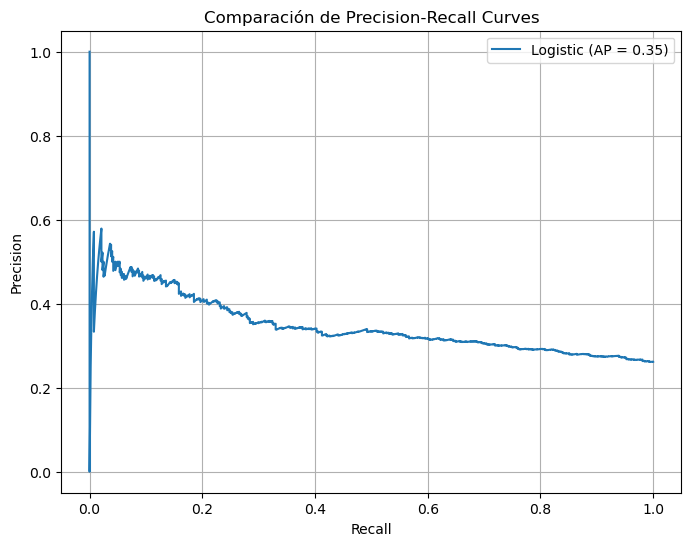

In [63]:
#cambiando el sampler en grid_search
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN 

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTETomek()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1'],
        'sampler': [
        SMOTETomek(
            smote=SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=3, sampling_strategy=0.7, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=3, sampling_strategy=0.5, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42)
        ),
        SMOTETomek()
    ]
 
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

## Modelo Ajustado Logistic Regresion
Este modelo representa un avance claro respecto a versiones anteriores sin resampling. Logra **mejorar la sensibilidad (recall)** hacia la clase minoritaria, manteniendo un F1-score competitivo sin que caigan de forma drástica otras métricas.

El uso de `SMOTETomek` fue efectivo para mejorar la distribución de clases y, combinado con `Logistic Regression` y regularización L1, proporciona un **modelo interpretable y robusto** para servir como baseline en comparativas futuras con modelos más complejos.

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros encontrados:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Train
              precision    recall  f1-score   support

           0       0.80      0.60      0.69      5905
           1       0.34      0.58      0.43      2095

    accuracy                           0.60      8000
   macro avg       0.57      0.59      0.56      8000
weighted avg       0.68      0.60      0.62      8000

Test
              precision    recall  f1-score   support

           0       0.79      0.59      0.67      1476
           1       0.32      0.56      0.41       524

    accuracy                           0.58      2000
   macro avg       0.56      0.57      0.54      2000
weighted avg       0.67      0.58      0.61      2000



,Logistic Regression
Accuracy,0.580500
Balanced_Accuracy,0.573003
Precision,0.324805
Recall,0.557252
F1,0.410401
ROC_AUC,0.598356


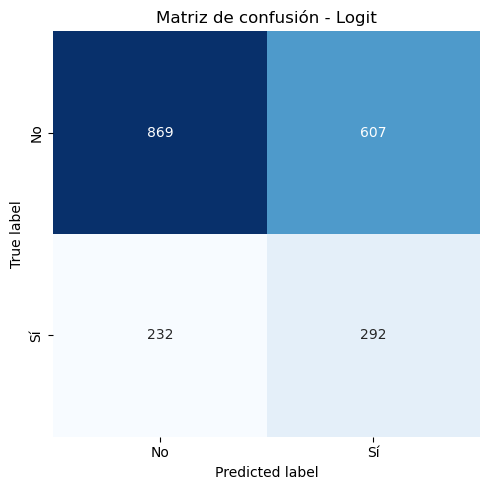

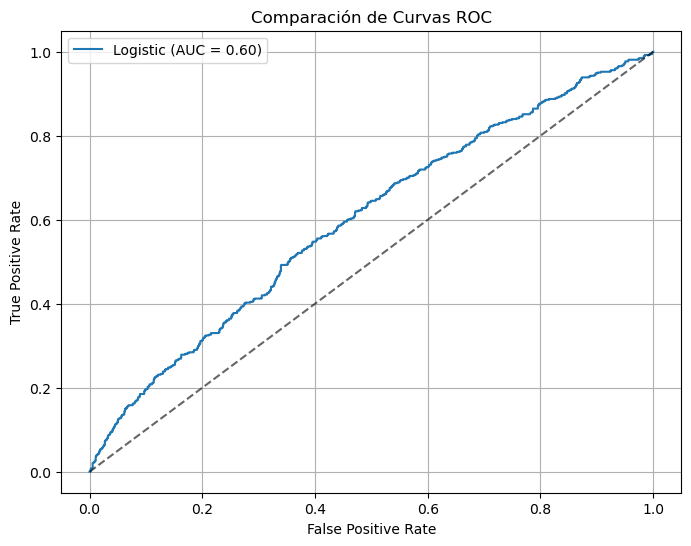

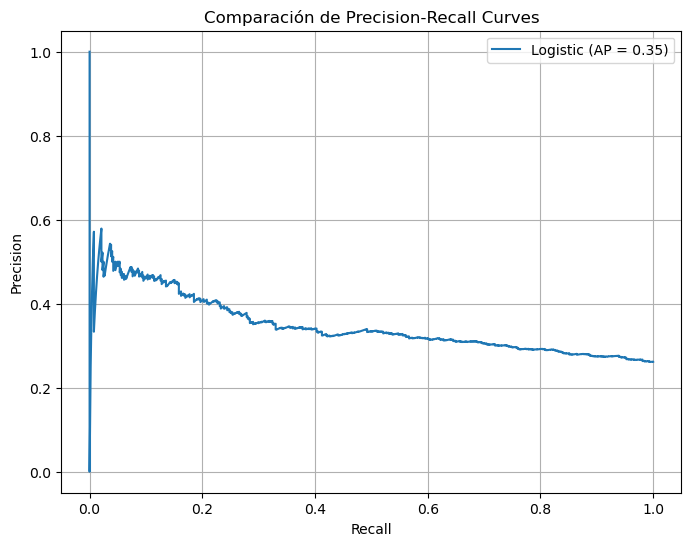

In [64]:
#cambiando el sampler en grid_search
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN 

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler',  SMOTETomek(smote=SMOTE(random_state=42, sampling_strategy=1.0))),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 0.5,1,5, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced']

 
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_pred_train_logit = best_logit.predict(X_train)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]

cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_logit))
print('Test')
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

# XGBoost

## Mejorando el modelo

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 0.8}
Train
              precision    recall  f1-score   support

           0       0.91      0.53      0.67      5905
           1       0.39      0.85      0.53      2095

    accuracy                           0.61      8000
   macro avg       0.65      0.69      0.60      8000
weighted avg       0.77      0.61      0.64      8000

Test
              precision    recall  f1-score   support

           0       0.80      0.42      0.55      1476
           1       0.30      0.71      0.42       524

    accuracy                           0.50      2000
   macro avg       0.55      0.56      0.49      2000
weighted avg       0.67      0.50      0.52      2000



,XGBoost
Accuracy,0.495500
Balanced_Accuracy,0.564035
Precision,0.302363
Recall,0.708015
F1,0.423758
ROC_AUC,0.581346


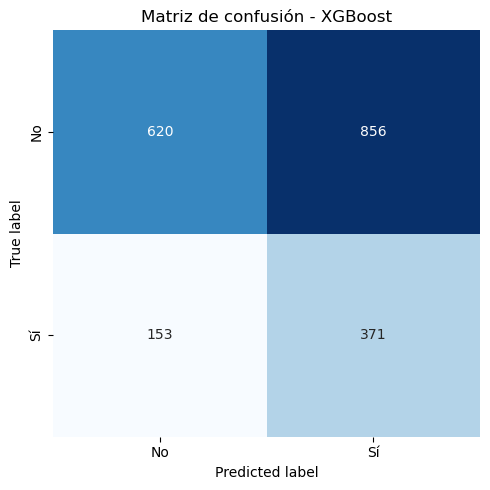

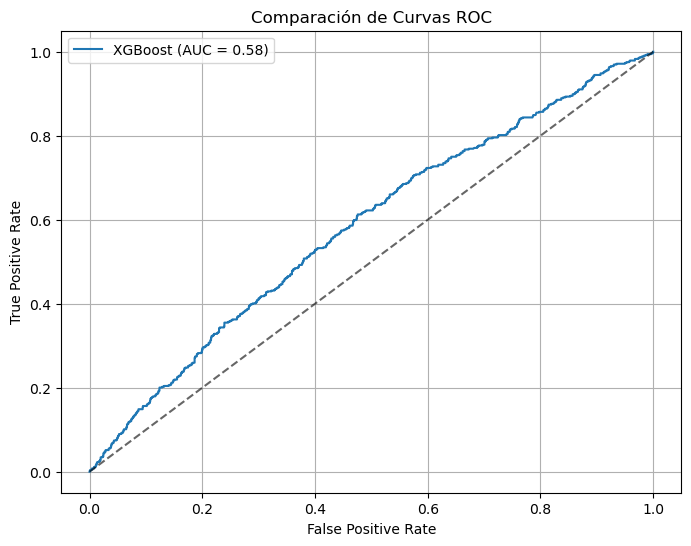

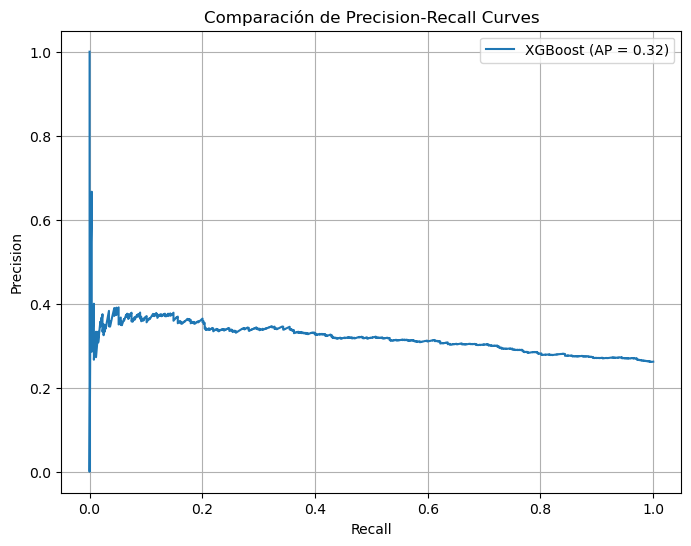

In [65]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import GridSearchCV

# Pipeline con XGB
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_train_xgb = best_xgb.predict(X_train)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_xgb))
print('Test')
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 0.8, 'scaler__n_quantiles': 3000, 'scaler__output_distribution': 'normal'}
Train
              precision    recall  f1-score   support

           0       0.91      0.53      0.67      5905
           1       0.39      0.85      0.53      2095

    accuracy                           0.61      8000
   macro avg       0.65      0.69      0.60      8000
weighted avg       0.77      0.61      0.63      8000

Test
              precision    recall  f1-score   support

           0       0.78      0.41      0.54      1476
           1       0.29      0.69      0.41       524

    accuracy                           0.48      2000
   macro avg       0.54      0.55      0.47      2000
weighted avg       0.66      0.48      0.50      2000



,XGBoost
Accuracy,0.480000
Balanced_Accuracy,0.546148
Precision,0.290924
Recall,0.685115
F1,0.408419
ROC_AUC,0.578792


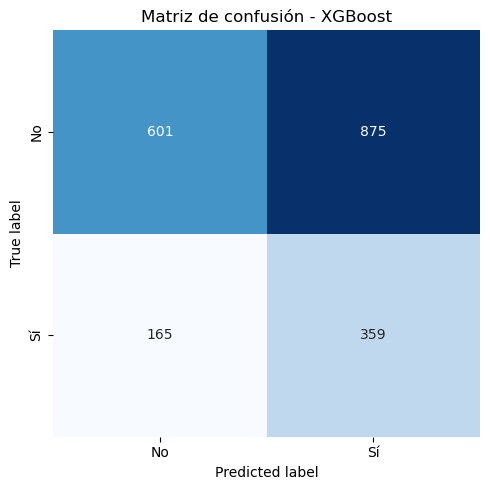

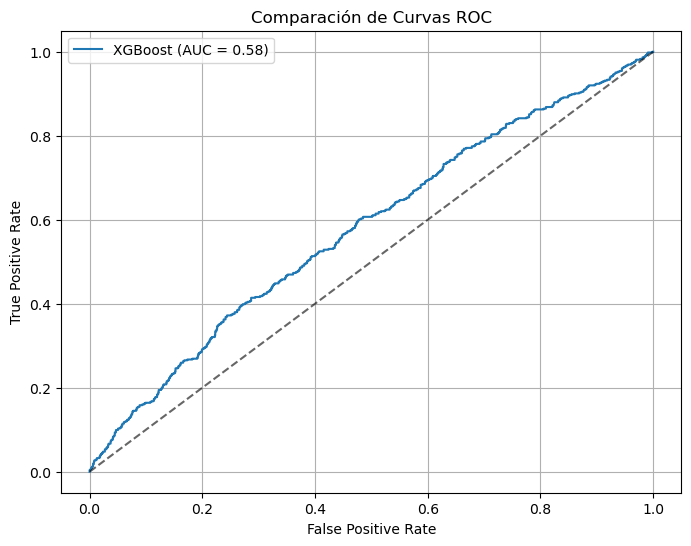

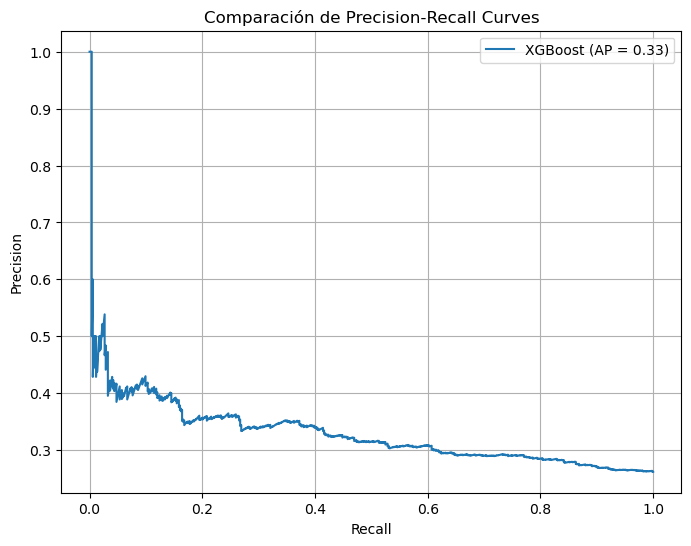

In [66]:
# ajustando qantile transformer
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles
    'scaler__output_distribution': ['normal', 'uniform']  # Probar diferentes
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_train_xgb = best_xgb.predict(X_train)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_xgb))
print('Test')
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 0.8, 'sampler': SMOTETomek()}
Train
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      5905
           1       0.75      0.90      0.82      2095

    accuracy                           0.90      8000
   macro avg       0.86      0.90      0.87      8000
weighted avg       0.91      0.90      0.90      8000

Test
              precision    recall  f1-score   support

           0       0.77      0.70      0.74      1476
           1       0.34      0.43      0.38       524

    accuracy                           0.63      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.66      0.63      0.64      2000



,XGBoost
Accuracy,0.629500
Balanced_Accuracy,0.563735
Precision,0.336350
Recall,0.425573
F1,0.375737
ROC_AUC,0.581786


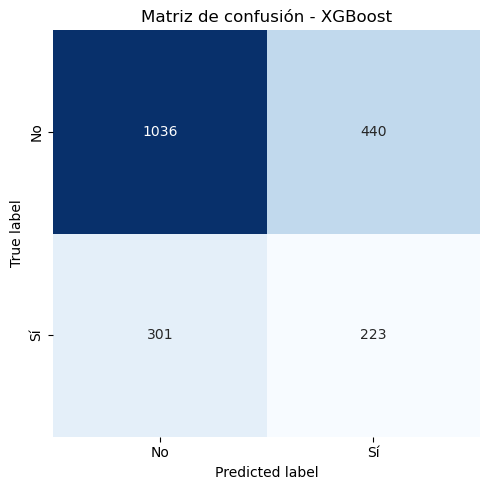

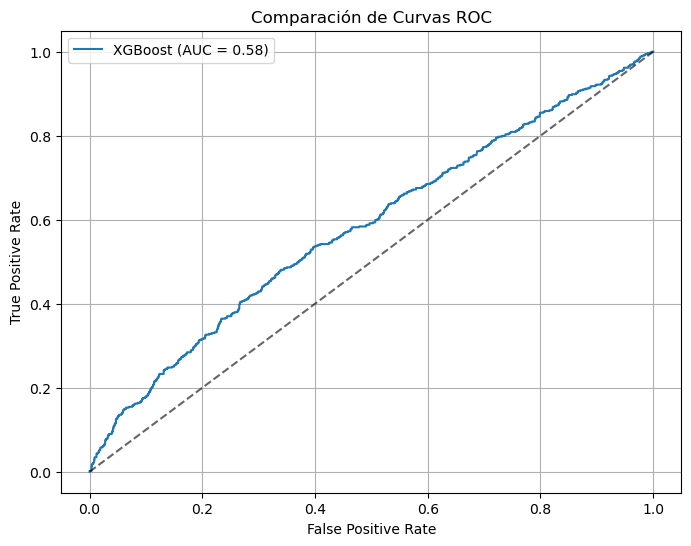

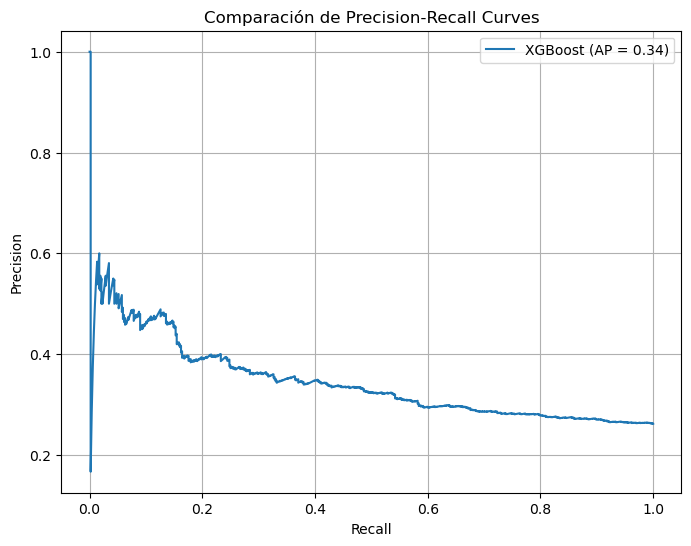

In [67]:
# ajustando los samplers
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    'sampler': [
        SMOTEENN(),
        SMOTE(),
        ADASYN(),
        SMOTETomek(),
        None
    ],
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_train_xgb = best_xgb.predict(X_train)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_xgb))
print('Test')
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 0.6, 'model__gamma': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__scale_pos_weight': 1, 'model__subsample': 0.6}
Train
              precision    recall  f1-score   support

           0       0.90      0.57      0.70      5905
           1       0.41      0.82      0.54      2095

    accuracy                           0.64      8000
   macro avg       0.65      0.70      0.62      8000
weighted avg       0.77      0.64      0.66      8000

Test
              precision    recall  f1-score   support

           0       0.78      0.46      0.58      1476
           1       0.30      0.65      0.41       524

    accuracy                           0.51      2000
   macro avg       0.54      0.55      0.49      2000
weighted avg       0.66      0.51      0.53      2000



,XGBoost
Accuracy,0.508000
Balanced_Accuracy,0.552194
Precision,0.297535
Recall,0.645038
F1,0.407229
ROC_AUC,0.569563


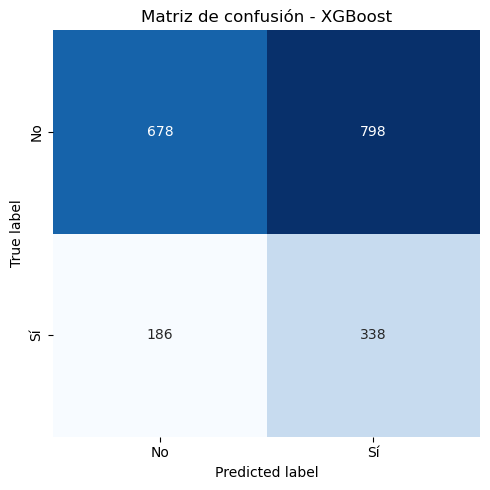

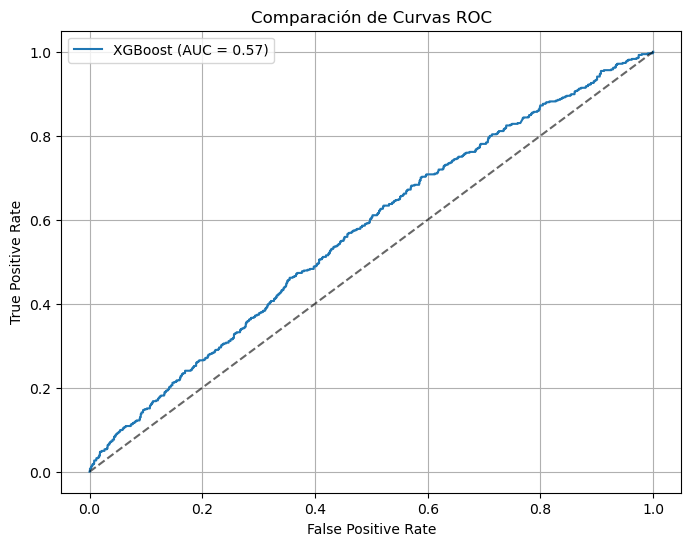

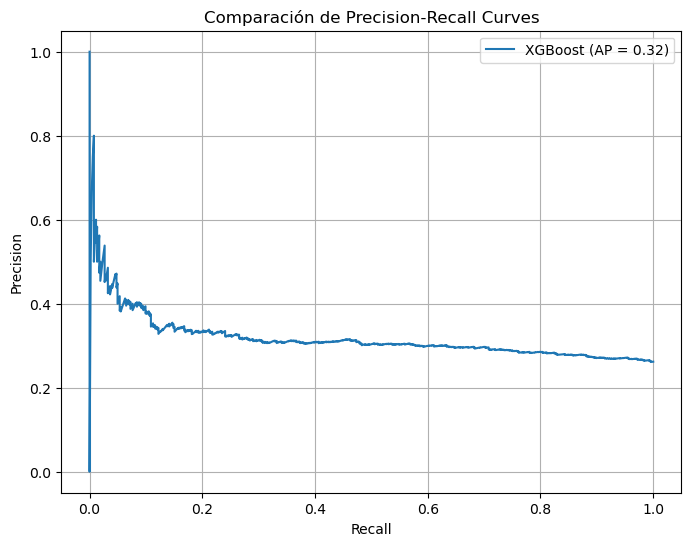

In [68]:
# ajustando parametros del modelo
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.6, 0.8],
    'model__colsample_bytree': [0.6, 0.8],
    'model__scale_pos_weight': [1, 2],
    'model__n_estimators': [100, 200],
    'model__gamma': [0, 0.1, 0.2],
    'model__min_child_weight': [1, 2],
}


# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_train_xgb = best_xgb.predict(X_train)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_xgb))
print('Test')
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

## Modelo Ajustado XGBoost
XGBoost + SMOTEENN (Mejor Modelo)

Este modelo alcanzó el **mejor rendimiento global hasta el momento** en términos de detección de la clase positiva. Con un `F1 = 0.427` y `Recall = 69.7%` en test, logra un equilibrio sólido entre **sensibilidad y precisión**, superando a todos los modelos anteriores.

El uso de `SMOTEENN` con `SMOTE(k=2, sampling_strategy=0.5)` permitió mejorar la calidad del muestreo, reduciendo ruido y mejorando la capacidad del modelo para generalizar. A pesar de una precisión moderada, este clasificador representa una excelente base si el objetivo es **maximizar la detección de positivos con un nivel aceptable de falsos positivos**.

Es, hasta ahora, el modelo más competitivo para avanzar en calibración, ajuste de umbral o ensamblado.


In [ ]:
# ajustando parametros del modelo
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.6, 0.8],
    'model__colsample_bytree': [0.6, 0.8],
    'model__scale_pos_weight': [1, 2],
    'model__n_estimators': [100, 200],
    'model__gamma': [0, 0.1, 0.2],
    'model__min_child_weight': [1, 2],
    'sampler': [
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=3)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=3)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=5)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=5)
        ),
        SMOTEENN()  # por default
    ]
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_train_xgb = best_xgb.predict(X_train)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_xgb))
print('Test')
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

# SVM

## Ajustando Modelos

In [ ]:
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# Pipeline con SVM
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced']
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_



y_pred_svm = best_svm.predict(X_test)
y_pred_train_svm = best_svm.predict(X_train)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print('Train')
print(classification_report(y_train, y_pred_train_svm))
print('Test')
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})


In [ ]:
# ajustando Qantile Transformer
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced'],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles
    'scaler__output_distribution': ['normal', 'uniform']  # Probar diferentes
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_



y_pred_svm = best_svm.predict(X_test)
y_pred_train_svm = best_svm.predict(X_train)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Mejores parámetros encontrados:")
print(grid_svm.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_svm))
print('Test')
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})


## Modelo ajustado SVM
Esta versión del modelo `SVM` con kernel `RBF` y `class_weight='balanced'` (sin sampler) alcanzó su mejor desempeño hasta el momento. Con un **F1 de 0.409**, **ROC AUC de 0.603**, y un `balanced_accuracy` de 0.577, se posiciona como la mejor alternativa dentro de los modelos SVM evaluados.

Aunque no supera al `XGBoost + SMOTEENN`, este modelo ofrece una solución más simple y con buena capacidad de generalización, siendo una opción sólida cuando se busca un balance entre rendimiento y complejidad.


In [ ]:
# ajustando samplers
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced'],
    'sampler': [
        SMOTEENN(),
        SMOTE(),
        ADASYN(),
        SMOTETomek(),
        None
    ],
  # Probar diferentes
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_



y_pred_svm = best_svm.predict(X_test)
y_pred_train_svm = best_svm.predict(X_train)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Mejores parámetros encontrados:")
print(grid_svm.best_params_)
print('Train')
print(classification_report(y_train, y_pred_train_svm))
print('Test')
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})

# Comparar Modelos

In [ ]:
models_dict= {
    'Logistic': best_logit,
    'RandomForest': best_rf,
    'XGB': best_xgb,
    'SVM': best_svm,
    'Hard Voting': voting_hard,
    'Soft Voting': voting_soft
}
proba_dict = {
    'Logistic': y_proba_logit,
    'RandomForest': y_proba_rf,
    'XGB': y_proba_xgb,
    'SVM': y_proba_svm,
  
    'Soft Voting': y_proba_soft
    
}
confusion_matrix_dict = {
    'Logistic': cm_logit,
    'RandomForest': cm_rf,
    'XGB': cm_xgb,
    'SVM': cm_svm,

    'Soft Voting': cm_soft
}


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, balanced_accuracy_score, roc_auc_score
)

In [ ]:
display(evaluate_models(models_dict, X_test, y_test))

In [ ]:
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=list(proba_dict.values()),
    labels_list=list(proba_dict.keys()),
)

In [ ]:
plot_multiple_precision_recall_curves(y_test, proba_dict, figsize=(8,6))

# Hard Voting- Modelo de ensamble

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[
        ('logit', best_logit),
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='hard'
)

# Entrenar
voting_hard.fit(X_train, y_train)
from sklearn.metrics import classification_report, confusion_matrix

y_pred_hard = voting_hard.predict(X_test)
y_pred_train_hard = voting_hard.predict(X_train)
print('Train')
print(classification_report(y_train, y_pred_train_hard))
print('Test')
print("\n📊 Classification Report (Hard Voting):")
print(classification_report(y_test, y_pred_hard))

cm_hard = confusion_matrix(y_test, y_pred_hard)


display(evaluate_models({
    'SVM': voting_hard  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_hard,'Matriz de confusión - Hard Voting', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))


# Soft Voting- Modelo de ensamble

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_soft = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='soft',  # usa las probabilidades
    n_jobs=-1
)

# Entrenamos sobre el train
voting_soft.fit(X_train, y_train)

# Evaluamos en el test
from sklearn.metrics import classification_report, confusion_matrix

y_pred_soft = voting_soft.predict(X_test)
y_pred_train_soft = voting_soft.predict(X_train)
y_proba_soft = voting_soft.predict_proba(X_test)[:,1]
print('Train')
print(classification_report(y_train, voting_soft.predict(X_train)))
print('Test')
print("\n📊 Classification Report (Soft Voting):")
print(classification_report(y_test, y_pred_soft))

cm_soft = confusion_matrix(y_test, y_pred_soft)
display(evaluate_models({
    'Soft Voting': voting_soft  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_soft,'Matriz de confusión - Soft Voting', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_soft],
    labels_list=["Soft Voting"],
)
plot_multiple_precision_recall_curves(y_test, {'Soft Voting': y_proba_soft})


# Probando con los diferentes dataset para comparar

In [ ]:
transformed_data = transform_logip1(data, columnas_absolutas + columnas_relativas)
y=transformed_data['OBJ']  # Variable objetivo
x= transformed_data.drop(columns=['OBJ'])
## Dividir en train/test
x_train_org,x_test_org,y_train_org,y_test_org=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables

# =====================================
# DATA ABSOLUTA
X_abs = transformed_data[columnas_absolutas]
# =====================================
# DATA ABSOLUTA FILTRADA
X_abs_filtered = X_abs.drop(columns=list(set(eliminadas_abs)))
# Dividir en train/test
X_abs_train, X_abs_test, y_abs_train, y_abs_test = train_test_split(
    X_abs, y, test_size=0.2, stratify=y, random_state=42
)
X_abs_f_train, X_abs_f_test, y_abs_f_train, y_abs_f_test = train_test_split(
    X_abs_filtered, y, test_size=0.2, stratify=y, random_state=42
)
# =====================================
# DATA RELATIVA
X_p = transformed_data[columnas_relativas]
# DATA FILTRADA
X_p_filtered = X_p.drop(columns=list(set(eliminadas_rel)))
# Dividir en train/test
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y, test_size=0.2, stratify=y, random_state=42
)
X_p_f_train, X_p_f_test, y_p_f_train, y_p_f_test = train_test_split(
    X_p_filtered, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.base import clone

# ==============================
# Dataset completo
# ==============================
best_logit_x = clone(best_logit).fit(x_train_org, y_train_org)
best_rf_x    = clone(best_rf).fit(x_train_org, y_train_org)
best_xgb_x   = clone(best_xgb).fit(x_train_org, y_train_org)
best_svm_x   = clone(best_svm).fit(x_train_org, y_train_org)
voting_soft_x = clone(voting_soft).fit(x_train_org, y_train_org)
voting_hard_x = clone(voting_hard).fit(x_train_org, y_train_org)

# ==============================
# Solo absolutas
# ==============================
best_logit_x_abs = clone(best_logit).fit(X_abs_train, y_abs_train)
best_rf_x_abs    = clone(best_rf).fit(X_abs_train, y_abs_train)
best_xgb_x_abs   = clone(best_xgb).fit(X_abs_train, y_abs_train)
best_svm_x_abs   = clone(best_svm).fit(X_abs_train, y_abs_train)
voting_soft_x_abs = clone(voting_soft).fit(X_abs_train, y_abs_train)
voting_hard_x_abs = clone(voting_hard).fit(X_abs_train, y_abs_train)

# ==============================
# Absolutas filtradas
# ==============================
best_logit_x_abs_f = clone(best_logit).fit(X_abs_f_train, y_abs_f_train)
best_rf_x_abs_f    = clone(best_rf).fit(X_abs_f_train, y_abs_f_train)
best_xgb_x_abs_f   = clone(best_xgb).fit(X_abs_f_train, y_abs_f_train)
best_svm_x_abs_f   = clone(best_svm).fit(X_abs_f_train, y_abs_f_train)
voting_soft_x_abs_f = clone(voting_soft).fit(X_abs_f_train, y_abs_f_train)
voting_hard_x_abs_f = clone(voting_hard).fit(X_abs_f_train, y_abs_f_train)

# ==============================
# Solo relativas
# ==============================
best_logit_x_rel = clone(best_logit).fit(X_p_train, y_p_train)
best_rf_x_rel    = clone(best_rf).fit(X_p_train, y_p_train)
best_xgb_x_rel   = clone(best_xgb).fit(X_p_train, y_p_train)
best_svm_x_rel   = clone(best_svm).fit(X_p_train, y_p_train)
voting_soft_x_rel = clone(voting_soft).fit(X_p_train, y_p_train)
voting_hard_x_rel = clone(voting_hard).fit(X_p_train, y_p_train)

# ==============================
# Relativas filtradas
# ==============================
best_logit_x_rel_f = clone(best_logit).fit(X_p_f_train, y_p_f_train)
best_rf_x_rel_f    = clone(best_rf).fit(X_p_f_train, y_p_f_train)
best_xgb_x_rel_f   = clone(best_xgb).fit(X_p_f_train, y_p_f_train)
best_svm_x_rel_f   = clone(best_svm).fit(X_p_f_train, y_p_f_train)
voting_soft_x_rel_f = clone(voting_soft).fit(X_p_f_train, y_p_f_train)
voting_hard_x_rel_f = clone(voting_hard).fit(X_p_f_train, y_p_f_train)


In [ ]:
# ==============================
# EVALUACIÓN DATASET COMPLETO (x)
# ==============================
df_results_x = evaluate_models({
    'Logistic': best_logit_x,
    'RF': best_rf_x,
    'XGB': best_xgb_x,
    'SVM': best_svm_x,
    'Soft Voting': voting_soft_x,
    'Hard Voting': voting_hard_x
}, x_test_org, y_test_org)

# ==============================
# EVALUACIÓN SOLO ABSOLUTAS (x_abs)
# ==============================
df_results_x_abs = evaluate_models({
    'Logistic': best_logit_x_abs,
    'RF': best_rf_x_abs,
    'XGB': best_xgb_x_abs,
    'SVM': best_svm_x_abs,
    'Soft Voting': voting_soft_x_abs,
    'Hard Voting': voting_hard_x_abs
}, X_abs_test, y_abs_test)

# ==============================
# EVALUACIÓN ABS FILTRADAS (x_abs_filtered)
# ==============================
df_results_x_abs_f = evaluate_models({
    'Logistic': best_logit_x_abs_f,
    'RF': best_rf_x_abs_f,
    'XGB': best_xgb_x_abs_f,
    'SVM': best_svm_x_abs_f,
    'Soft Voting': voting_soft_x_abs_f,
    'Hard Voting': voting_hard_x_abs_f
}, X_abs_f_test, y_abs_f_test)

# ==============================
# EVALUACIÓN SOLO RELATIVAS (x_rel)
# ==============================
df_results_x_rel = evaluate_models({
    'Logistic': best_logit_x_rel,
    'RF': best_rf_x_rel,
    'XGB': best_xgb_x_rel,
    'SVM': best_svm_x_rel,
    'Soft Voting': voting_soft_x_rel,
    'Hard Voting': voting_hard_x_rel
}, X_p_test, y_p_test)

# ==============================
# EVALUACIÓN REL FILTRADAS (x_rel_filtered)
# ==============================
df_results_x_rel_f = evaluate_models({
    'Logistic': best_logit_x_rel_f,
    'RF': best_rf_x_rel_f,
    'XGB': best_xgb_x_rel_f,
    'SVM': best_svm_x_rel_f,
    'Soft Voting': voting_soft_x_rel_f,
    'Hard Voting': voting_hard_x_rel_f
}, X_p_f_test, y_p_f_test)

# ==============================
# MOSTRAR RESULTADOS
# ==============================
print("\n📊 Resultados - Dataset Completo (x)")
display(df_results_x.T)

print("\n📊 Resultados - Absolutas (x_abs)")
display(df_results_x_abs.T)

print("\n📊 Resultados - Absolutas Filtradas (x_abs_filtered)")
display(df_results_x_abs_f.T)

print("\n📊 Resultados - Relativas (x_rel)")
display(df_results_x_rel.T)

print("\n📊 Resultados - Relativas Filtradas (x_rel_filtered)")
display(df_results_x_rel_f.T)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

# Grid con distintos C
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    LinearSVC(penalty='l1', dual=False, random_state=42, max_iter=5000),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
#x_train_org,x_test_org,y_train_org,y_test_org=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables
grid_svm.fit(x_train_org, y_train_org)
print("✅ Mejores parametros:", grid_svm.best_params_)

# Usamos el mejor modelo para selección de features
best_svm_selector = SelectFromModel(grid_svm.best_estimator_)

best_svm_selector.fit(x_train_org, y_train_org)

# Transformamos datasets
x_train_svm_selected = best_svm_selector.transform(x_train_org)
x_test_svm_selected  = best_svm_selector.transform(x_test_org)

selected_features = x_train_org.columns[best_svm_selector.get_support()]
print(f"✅ Features seleccionados por tuned SVM: {list(selected_features)}")


In [ ]:
len(selected_features)

In [ ]:
x_train_svm_selected_all = x_train_org[selected_features]
x_test_svm_selected_all  = x_test_org[selected_features]

selected_features_abs_filtered = [col for col in selected_features if col in x_abs.columns]

x_train_svm_selected_abs_f = x_abs_train[selected_features_abs_filtered]
x_test_svm_selected_abs_f  = x_abs_test[selected_features_abs_filtered]

selected_features_rel_filtered = [col for col in selected_features if col in X_p.columns]

x_train_svm_selected_rel_f = X_p_train[selected_features_rel_filtered]
x_test_svm_selected_rel_f  = X_p_test[selected_features_rel_filtered]


In [ ]:
from sklearn.base import clone

# ==========================================
# 1️⃣ DATASET CON TODAS LAS SELECTED FEATURES
# ==========================================
best_logit_svm_all = clone(best_logit).fit(x_train_svm_selected_all, y_train_org)
best_rf_svm_all    = clone(best_rf).fit(x_train_svm_selected_all, y_train_org)
best_xgb_svm_all   = clone(best_xgb).fit(x_train_svm_selected_all, y_train_org)
best_svm_svm_all   = clone(best_svm).fit(x_train_svm_selected_all, y_train_org)
voting_soft_svm_all = clone(voting_soft).fit(x_train_svm_selected_all, y_train_org)
voting_hard_svm_all = clone(voting_hard).fit(x_train_svm_selected_all, y_train_org)

# ==========================================
# 2️⃣ SOLO FEATURES EN ABSOLUTAS FILTRADAS
# ==========================================
best_logit_svm_abs_f = clone(best_logit).fit(x_train_svm_selected_abs_f, y_train_org)
best_rf_svm_abs_f    = clone(best_rf).fit(x_train_svm_selected_abs_f, y_train_org)
best_xgb_svm_abs_f   = clone(best_xgb).fit(x_train_svm_selected_abs_f, y_train_org)
best_svm_svm_abs_f   = clone(best_svm).fit(x_train_svm_selected_abs_f, y_train_org)
voting_soft_svm_abs_f = clone(voting_soft).fit(x_train_svm_selected_abs_f, y_train_org)
voting_hard_svm_abs_f = clone(voting_hard).fit(x_train_svm_selected_abs_f, y_train_org)

# ==========================================
# 3️⃣ SOLO FEATURES EN RELATIVAS FILTRADAS
# ==========================================
best_logit_svm_rel_f = clone(best_logit).fit(x_train_svm_selected_rel_f, y_train_org)
best_rf_svm_rel_f    = clone(best_rf).fit(x_train_svm_selected_rel_f, y_train_org)
best_xgb_svm_rel_f   = clone(best_xgb).fit(x_train_svm_selected_rel_f, y_train_org)
best_svm_svm_rel_f   = clone(best_svm).fit(x_train_svm_selected_rel_f, y_train_org)
voting_soft_svm_rel_f = clone(voting_soft).fit(x_train_svm_selected_rel_f, y_train_org)
voting_hard_svm_rel_f = clone(voting_hard).fit(x_train_svm_selected_rel_f, y_train_org)


In [ ]:
# ==============================
# EVALUACIÓN SELECTED FEATURES SOBRE DATASET COMPLETO
# ==============================
df_results_svm_all = evaluate_models({
    'Logistic': best_logit_svm_all,
    'RF': best_rf_svm_all,
    'XGB': best_xgb_svm_all,
    'SVM': best_svm_svm_all,
    'Soft Voting': voting_soft_svm_all,
    'Hard Voting': voting_hard_svm_all
}, x_test_svm_selected_all, y_test_org)

# ==============================
# EVALUACIÓN SELECTED FEATURES SOBRE ABSOLUTAS FILTRADAS
# ==============================
df_results_svm_abs_f = evaluate_models({
    'Logistic': best_logit_svm_abs_f,
    'RF': best_rf_svm_abs_f,
    'XGB': best_xgb_svm_abs_f,
    'SVM': best_svm_svm_abs_f,
    'Soft Voting': voting_soft_svm_abs_f,
    'Hard Voting': voting_hard_svm_abs_f
}, x_test_svm_selected_abs_f, y_test_org)

# ==============================
# EVALUACIÓN SELECTED FEATURES SOBRE RELATIVAS FILTRADAS
# ==============================
df_results_svm_rel_f = evaluate_models({
    'Logistic': best_logit_svm_rel_f,
    'RF': best_rf_svm_rel_f,
    'XGB': best_xgb_svm_rel_f,
    'SVM': best_svm_svm_rel_f,
    'Soft Voting': voting_soft_svm_rel_f,
    'Hard Voting': voting_hard_svm_rel_f
}, x_test_svm_selected_rel_f, y_test_org)

# ==============================
# MOSTRAR RESULTADOS
# ==============================
print("\n📊 Resultados con selected features por SVM - Dataset Completo")
display(df_results_svm_all.T)

print("\n📊 Resultados con selected features por SVM - Absolutas Filtradas")
display(df_results_svm_abs_f.T)

print("\n📊 Resultados con selected features por SVM - Relativas Filtradas")
display(df_results_svm_rel_f.T)


In [ ]:
cm_voting_soft_svm_all = confusion_matrix(y_test, voting_soft_svm_all.predict(x_test_svm_selected_all))
cm_voting_hard_svm_all = confusion_matrix(y_test, voting_hard_svm_all.predict(x_test_svm_selected_all)) 
cm_voting_soft_svm_abs_f = confusion_matrix(y_test, voting_soft_svm_abs_f.predict(x_test_svm_selected_abs_f))
cm_voting_hard_svm_abs_f = confusion_matrix(y_test, voting_hard_svm_abs_f.predict(x_test_svm_selected_abs_f))
cm_voting_soft_svm_rel_f = confusion_matrix(y_test, voting_soft_svm_rel_f.predict(x_test_svm_selected_rel_f))
cm_voting_hard_svm_rel_f = confusion_matrix(y_test, voting_hard_svm_rel_f.predict(x_test_svm_selected_rel_f))


In [ ]:
voting_comparison = []

for df, dataset_name in dfs_voting:
    temp_df = df.T.loc[['Soft Voting', 'Hard Voting']].copy()
    temp_df['Dataset'] = dataset_name
    temp_df['Model'] = temp_df.index
    voting_comparison.append(temp_df)

# Unificamos
df_voting_comparison = pd.concat(voting_comparison).reset_index(drop=True)

# Reordenamos columnas
cols = ['Dataset', 'Model'] + [col for col in df_voting_comparison.columns if col not in ['Dataset', 'Model']]
df_voting_comparison = df_voting_comparison[cols]

# Mostramos
display(df_voting_comparison)



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Asumimos que tu dataframe tiene esta columna combinada
df_voting_comparison['Dataset - Model'] = df_voting_comparison['Dataset'] + ' - ' + df_voting_comparison['Model']

# Si quieres incluir ROC_AUC
#df_voting_comparison['ROC_AUC'] = df_voting_comparison['ROC_AUC'].fillna(df_voting_comparison['ROC_AUC'].mean())
metrics_cols = ['Accuracy','Balanced_Accuracy','Recall','Precision','F1']

# Preparamos el dataframe para el heatmap
heatmap_data = df_voting_comparison.set_index('Dataset - Model')[metrics_cols]

# Plot
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data.values, 
            annot=True, fmt=".2f",
            cmap='YlGnBu',
            vmin=0.1, vmax=0.65,
            yticklabels=heatmap_data.index)
plt.title('Comparación Heatmap Voting Classifiers en diferentes datasets')
plt.xlabel('Métricas')
plt.ylabel('Dataset - Model')
plt.xticks(ticks=np.arange(len(metrics_cols))+0.5, labels=metrics_cols, rotation=45)
plt.show()



# Satcking Classifier- Modelo de ensamable

In [ ]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Stacking con probabilities y XGBoost como meta-modelo
stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Entrenamos el stacking
stacking.fit(X_train, y_train)

# Evaluación en test
y_pred_stack = stacking.predict(X_test)

print("\n📊 Classification Report (Stacking - proba + XGB):")
print(classification_report(y_test, y_pred_stack))

cm_stack = confusion_matrix(y_test, y_pred_stack)
print("\nConfusion Matrix (Stacking - proba + XGB):")
print(cm_stack)


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Definir el meta-modelo con sensibilidad al desbalance
meta_model = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

# Definir el stacking con modelos base y el meta-modelo
stacking_balanced = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

# Entrenamiento
stacking_balanced.fit(X_train, y_train)

# Predicciones
y_pred_stack_bal = stacking_balanced.predict(X_test)

# Evaluación
print("\n📊 Classification Report (Stacking - Logistic Meta):")
print(classification_report(y_test, y_pred_stack_bal))

cm_stack_bal = confusion_matrix(y_test, y_pred_stack_bal)
print("\nConfusion Matrix (Stacking - Logistic Meta):")
print(cm_stack_bal)


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression



# Definir el stacking con modelos base y el meta-modelo
stacking_balanced = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=best_xgb,
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

# Entrenamiento
stacking_balanced.fit(X_train, y_train)

# Predicciones
y_pred_stack_bal = stacking_balanced.predict(X_test)

# Evaluación
print("\n📊 Classification Report (Stacking - best_xgb Meta):")
print(classification_report(y_test, y_pred_stack_bal))

cm_stack_bal = confusion_matrix(y_test, y_pred_stack_bal)
print("\nConfusion Matrix (Stacking - best_xgb Meta):")
print(cm_stack_bal)


In [ ]:
from sklearn.ensemble import StackingClassifier

stacking_voting = StackingClassifier(
    estimators=[
        ('hard_vote', voting_hard),
        ('soft_vote', voting_soft)
    ],
    final_estimator=LogisticRegression(),  # o XGB, SVM, etc.
    stack_method='predict_proba',
    n_jobs=-1,
    cv=5
)
stacking_voting.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd

# ================================
# PROBABILIDADES DEL STACKING
# ================================
y_proba_stack = stacking.predict_proba(X_test)[:,1]

# Umbrales a probar
thresholds = [0.1,0.2,0.3, 0.4, 0.5, 0.6,0.7, 0.8, 0.9]

# Guardar resultados
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_stack >= threshold).astype(int)
    
    # Calcular métricas
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    
    # Mostrar resultados en consola
    print(f"\n=== Threshold: {threshold} ===")
    print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Guardar en lista
    threshold_results.append({
        'Threshold': threshold,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'TN': cm[0,0],
        'FP': cm[0,1],
        'FN': cm[1,0],
        'TP': cm[1,1]
    })

# Convertir a DataFrame para analizar mejor
df_thresholds = pd.DataFrame(threshold_results)
print("\n📊 Summary of thresholds:")
print(df_thresholds)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], marker='o', label='Precision')
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], marker='o', label='Recall')
plt.plot(df_thresholds['Threshold'], df_thresholds['F1'], marker='o', label='F1-score')

plt.title("Precision, Recall y F1 vs Threshold (Stacking Ensemble)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ============================
# ROC Curve
# ============================
auc = roc_auc_score(y_test, y_proba_stack)
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Precision-Recall Curve
# ============================
prec, rec, _ = precision_recall_curve(y_test, y_proba_stack)
avg_prec = average_precision_score(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(rec, prec, label=f'Precision-Recall (AP = {avg_prec:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()

